# **Analisis Sentimen Mobile JKN**



## **1. Menghubungkan Google Drive**

In [65]:
import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Google Drive tidak di-mount karena notebook dijalankan di luar Google Colab.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Instalasi dan Import Library**


In [66]:
# Install library yang belum tersedia secara default di Google Colab
!pip install Sastrawi -q

In [67]:
import re
import html
import joblib
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from functools import lru_cache
from tqdm.auto import tqdm
from IPython.display import display, Markdown
from matplotlib.font_manager import findfont
from matplotlib.ticker import MaxNLocator
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
URUTAN_LABEL = ["negatif", "netral", "positif"]
WARNA_SENTIMEN = {
    "negatif": "#C94C4C",
    "netral": "#F0A23B",
    "positif": "#2E8B57",
}

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## **3. Menentukan Lokasi File**

Notebook membaca file yang sudah tersedia di folder proyek. Dataset tidak
diunduh, tidak di-scrape ulang, dan file label manual tidak ditimpa.

In [68]:
PROJECT_DIR = os.environ.get(
    "MOBILE_JKN_PROJECT_DIR",
    "/content/drive/MyDrive/DA PPKD/PBL",
)

# =========================================================
# PATH DATA
# =========================================================

PATH_LABEL = os.path.join(
    PROJECT_DIR,
    "mobile_jkn_label_manual_final.csv"
)

PATH_RAW = os.path.join(
    PROJECT_DIR,
    "mobile_jkn_juni_agustus_2026.csv"
)


# =========================================================
# FOLDER FINAL MODEL, TF-IDF, DAN HASIL PREDIKSI
# =========================================================

FOLDER_FINAL_MODEL = os.path.join(
    PROJECT_DIR,
    "Model.pkl, Tfidf.pkl dan Hasil Akhir Prediksi Sentimen"
)

os.makedirs(FOLDER_FINAL_MODEL, exist_ok=True)

PATH_MODEL = os.path.join(
    FOLDER_FINAL_MODEL,
    "model.pkl"
)

PATH_TFIDF = os.path.join(
    FOLDER_FINAL_MODEL,
    "tfidf.pkl"
)

PATH_PREDIKSI = os.path.join(
    FOLDER_FINAL_MODEL,
    "Hasil Akhir Final Distribusi Sentimen dari Prediksi Model.csv"
)


# =========================================================
# FOLDER HASIL ANALISIS
# =========================================================

FOLDER_HASIL = os.path.join(
    PROJECT_DIR,
    "Output Hasil Analisis"
)

FOLDER_GRAFIK = os.path.join(
    FOLDER_HASIL,
    "Grafik & Wordcloud"
)

os.makedirs(FOLDER_GRAFIK, exist_ok=True)

## **4. Membaca Dataset**

Dataset berlabel dipakai untuk pelatihan (train) dan evaluasi model. Dataset RAW tidak digunakan untuk melatih model, tetapi diproses setelah model final terbentuk untuk memperoleh prediksi sentimen seluruh ulasan.

In [69]:
if not os.path.exists(PATH_LABEL):
    raise FileNotFoundError(f"File label manual tidak ditemukan: {PATH_LABEL}")

if not os.path.exists(PATH_RAW):
    raise FileNotFoundError(f"File RAW tidak ditemukan: {PATH_RAW}")

df_label = pd.read_csv(
    PATH_LABEL,
    dtype={"id": "string", "teks": "string"},
    keep_default_na=False,
)

df_raw = pd.read_csv(
    PATH_RAW,
    dtype={"id": "string", "teks": "string"},
    keep_default_na=False,
)

df_label.columns = df_label.columns.str.strip().str.lower()
df_raw.columns = df_raw.columns.str.strip().str.lower()

print("Data berlabel:", df_label.shape)
print("Data RAW:", df_raw.shape)
display(df_label.head(3))
display(df_raw.head(3))

Data berlabel: (1435, 7)
Data RAW: (12105, 5)


,id,teks,rating,tanggal,jam,bulan,label_sentimen
0,000168e5-f4a4-49c5-93fd-35e3e3ada76c,aplikasi membantu,5,2026-07-21,21,Juli,positif
1,002a28f5-1509-429a-add1-ac64cca1b65f,"apk jelek, sampah, gw gk bisa daftar, kode otp gak masuk2, apk gak guna",1,2026-07-02,18,Juli,negatif
2,006020aa-5cc7-4654-9621-28573d91cb14,efektifitas mantaf,5,2026-08-14,16,Agustus,positif


,id,teks,rating,tanggal,jam
0,afc4dbfc-10a7-4be4-a703-7d18b2898a78,"Makin parah nih apk nya. Iuran udah di bayar, tapi status keanggotaan nya masih tidak aktif. Ini saya mau cek iuran ...",2,2026-06-01,0
1,3bac7ee0-3beb-438c-b242-08bfe9547e9a,aplikasi JKN ini sangat mempermudah dalam pelayanan kesehatan kami sekeluarga,5,2026-06-01,0
2,6dad03f2-eff6-4c20-8eea-cb3c3fa21030,APLIKASI KALAU LAGI URGENT DI BUTUHKAN MALAH OFFLINE ! MANTAP,1,2026-06-01,1


## **5. Validasi Data**
Tahap ini memastikan:
*   ID tidak ada missing value dan data duplikat
*   rating berada pada 1–5
*   label hanya negatif/netral/positif

In [70]:
KOLOM_LABEL = ["id", "teks", "rating", "tanggal", "jam", "bulan", "label_sentimen"]
KOLOM_RAW = ["id", "teks", "rating", "tanggal", "jam"]

kolom_label_hilang = [kolom for kolom in KOLOM_LABEL if kolom not in df_label.columns]
kolom_raw_hilang = [kolom for kolom in KOLOM_RAW if kolom not in df_raw.columns]

if kolom_label_hilang:
    raise ValueError(f"Kolom data berlabel belum lengkap: {kolom_label_hilang}")
if kolom_raw_hilang:
    raise ValueError(f"Kolom data RAW belum lengkap: {kolom_raw_hilang}")

df_label["id"] = df_label["id"].str.strip()
df_raw["id"] = df_raw["id"].str.strip()
df_label["label_sentimen"] = df_label["label_sentimen"].str.strip().str.casefold()

if df_label["id"].eq("").any() or df_label["id"].duplicated().any():
    raise ValueError("Data berlabel memiliki ID kosong atau duplikat.")
if df_raw["id"].eq("").any() or df_raw["id"].duplicated().any():
    raise ValueError("Data RAW memiliki ID kosong atau duplikat.")
if df_label["teks"].str.strip().eq("").any():
    raise ValueError("Data berlabel memiliki teks kosong.")
if not pd.to_numeric(df_label["rating"], errors="coerce").isin(range(1, 6)).all():
    raise ValueError("Rating pada data berlabel harus berada pada rentang 1–5.")
if not df_label["label_sentimen"].isin(URUTAN_LABEL).all():
    raise ValueError("Ditemukan label di luar negatif, netral, dan positif.")
if set(df_label["label_sentimen"]) != set(URUTAN_LABEL):
    raise ValueError("Ketiga kelas sentimen harus tersedia sebelum pemodelan.")

jumlah_label_manual = (
    df_label["label_sentimen"]
    .value_counts()
    .reindex(URUTAN_LABEL, fill_value=0)
)

distribusi_label_manual = pd.DataFrame({
    "Jumlah": jumlah_label_manual,
    "Persentase (%)": (jumlah_label_manual / len(df_label) * 100).round(2),
})
distribusi_label_manual.index.name = "Label Manual"

print("Jumlah data berlabel:", len(df_label))
print("Jumlah data RAW:", len(df_raw))
display(distribusi_label_manual)

Jumlah data berlabel: 1435
Jumlah data RAW: 12105


,Jumlah,Persentase (%)
Label Manual,,
negatif,605,42.16
netral,263,18.33
positif,567,39.51


Belum sepenuhnya seimbang. Negatif dan positif relatif dekat, sedangkan netral lebih sedikit. Karena itu **evaluasi model** tidak hanya menggunakan accuracy, tetapi juga **F1 Macro**.

In [71]:
# Mengambil semua baris yang memiliki teks sama persis
duplikat_identik = df_label[
    df_label.duplicated(subset=["teks"], keep=False)
].copy()

# Menghitung kelompok teks berulang dan jumlah duplikat tambahannya
jumlah_kelompok_duplikat = int(duplikat_identik["teks"].nunique())
jumlah_duplikat_tambahan = int(
    df_label.duplicated(subset=["teks"], keep="first").sum()
)

print("Kelompok teks identik:", jumlah_kelompok_duplikat)
print("Duplikat tambahan:", jumlah_duplikat_tambahan)

if not duplikat_identik.empty:
    # Menampilkan teks berulang beserta jumlah kemunculannya
    tabel_rincian = (
        duplikat_identik.groupby("teks")
        .size()
        .reset_index(name="Jumlah Kemunculan")
        .sort_values("Jumlah Kemunculan", ascending=False)
    )
    display(tabel_rincian)


Kelompok teks identik: 36
Duplikat tambahan: 200


,teks,Jumlah Kemunculan
6,bagus,36
24,sangat membantu,33
15,mantap,28
18,ok,27
12,good,15
0,Alhamdulillah,9
8,baik,8
19,oke,8
14,keren,5
21,sangat baik,4


## **6. Preprocessing**


### **Cleaning**

Cleaning menyeragamkan huruf serta menghapus URL, HTML, mention, tanda baca,
emoji, dan spasi berlebih.


In [72]:
def cleaning(teks):
    """Membersihkan karakter yang tidak diperlukan tanpa mengubah label."""
    if pd.isna(teks):
        return ""

    teks = html.unescape(str(teks))
    teks = unicodedata.normalize("NFKC", teks).casefold()
    teks = re.sub(r"https?://\S+|www\.\S+", " ", teks)
    teks = re.sub(r"<[^>]*>", " ", teks)
    teks = re.sub(r"@\w+", " ", teks)
    teks = re.sub(r"[^a-z0-9\s]", " ", teks)
    return re.sub(r"\s+", " ", teks).strip()


# Menyalin data manual agar file sumber tidak berubah
df_preprocessing = df_label.copy()

# Menerapkan cleaning pada kolom teks
tqdm.pandas(desc="Cleaning data berlabel")
df_preprocessing["teks_clean"] = (
    df_preprocessing["teks"].progress_apply(cleaning)
)

print("Cleaning selesai untuk", len(df_preprocessing), "baris.")

# Menampilkan contoh ulasan asli dan hasil cleaning agar perubahannya mudah dilihat
contoh_hasil_cleaning = (
    df_preprocessing[["teks", "teks_clean"]]
    .head(5)
    .rename(columns={
        "teks": "Ulasan Asli",
        "teks_clean": "Hasil Cleaning",
    })
)

print("Contoh ulasan sebelum dan sesudah cleaning:")
display(contoh_hasil_cleaning)


Cleaning data berlabel:   0%|          | 0/1435 [00:00<?, ?it/s]

Cleaning selesai untuk 1435 baris.
Contoh ulasan sebelum dan sesudah cleaning:


,Ulasan Asli,Hasil Cleaning
0,aplikasi membantu,aplikasi membantu
1,"apk jelek, sampah, gw gk bisa daftar, kode otp gak masuk2, apk gak guna",apk jelek sampah gw gk bisa daftar kode otp gak masuk2 apk gak guna
2,efektifitas mantaf,efektifitas mantaf
3,aplikasi ga jelas ngirim kode otp ga bisa bisa,aplikasi ga jelas ngirim kode otp ga bisa bisa
4,aplikasi gagal tiap verifikasi force close sampah,aplikasi gagal tiap verifikasi force close sampah


### **Normalisasi**

Normalisasi mengubah kata tidak baku dan typo yang sudah ditentukan dalam
kamus, misalnya `gak` menjadi `tidak` dan `eror` menjadi `error`.


In [73]:
KAMUS_NORMALISASI = {
    # Frasa dan penulisan terpisah
    "thanks you so much": "terima kasih banyak", "so far so good": "sejauh ini bagus", "is very good": "sangat bagus", "is the best": "yang terbaik",
    "i like it": "saya suka", "good job": "kerja bagus", "gopd job": "kerja bagus", "made in": "buatan",
    "log in": "login", "log-in": "login", "log out": "logout", "log-out": "logout",
    "log'out": "logout", "call center": "pusat panggilan", "mudah mudahan": "semoga", "matur nuwun": "terima kasih",
    "terima ksh": "terima kasih", "trima kasih": "terima kasih", "ganggu ann": "gangguan", "ketidak nyamanan": "ketidaknyamanan",
    "sat set": "cepat", "boro boro": "jangankan", "gonta ganti": "berganti-ganti", "sorry to say": "maaf mengatakan",
    "hana jelah": "hanya jelek", "cepat d bagus": "cepat dan bagus", "tidak guna": "tidak berguna", "ga guna": "tidak berguna",
    "gak guna": "tidak berguna", "gk guna": "tidak berguna", "ngga guna": "tidak berguna", "nggak guna": "tidak berguna",
    "tidak bisa bisa": "tidak bisa", "tidak masuk masuk": "tidak masuk", "tidak muncul muncul": "tidak muncul", "tidak dikirim dikirim": "tidak dikirim",
    "tidak terkirim terkirim": "tidak terkirim", "ke krim": "terkirim", "di download": "diunduh", "di instal": "diinstal",
    "di install": "diinstal", "di uninstall": "dihapus instalasinya", "di perbaiki": "diperbaiki", "di buka": "dibuka",
    "di kirim": "dikirim", "di gunakan": "digunakan", "di pakai": "dipakai", "di hapus": "dihapus",
    "di klik": "diklik", "di batalkan": "dibatalkan", "di persulit": "dipersulit", "di permudah": "dipermudah",
    "di masukan": "dimasukkan", "di isi": "diisi", "di coba": "dicoba", "di suruh": "disuruh",
    "di kasih": "diberi", "di cek": "dicek", "ti dak": "tidak",

    # Negasi dan bentuk kata yang menempel
    "g": "tidak", "ga": "tidak", "gak": "tidak", "gk": "tidak",
    "gag": "tidak", "gg": "tidak", "kg": "tidak", "kgk": "tidak",
    "ngga": "tidak", "nggak": "tidak", "nggk": "tidak", "ngak": "tidak",
    "nga": "tidak", "ngk": "tidak", "enggak": "tidak", "engga": "tidak",
    "enggk": "tidak", "egk": "tidak", "kagak": "tidak", "kaga": "tidak",
    "ndak": "tidak", "dak": "tidak", "tdk": "tidak", "tdak": "tidak",
    "tidk": "tidak", "tidaj": "tidak", "tda": "tidak", "tak": "tidak",
    "ora": "tidak", "gabisa": "tidak bisa", "gakbisa": "tidak bisa", "gbisa": "tidak bisa",
    "gbs": "tidak bisa", "gabisa2": "tidak bisa", "gajelas": "tidak jelas", "gjlss": "tidak jelas",
    "gaada": "tidak ada", "gda": "tidak ada", "gausah": "tidak usah", "gaush": "tidak usah",
    "gosah": "tidak usah", "gamasuk": "tidak masuk", "gamasukkk": "tidak masuk", "gajadi": "tidak jadi",
    "gaguna": "tidak berguna", "gprnh": "tidak pernah", "gatau": "tidak tahu", "ggaakk": "tidak",
    "tapigk": "tapi tidak", "useeless": "tidak berguna", "can't": "tidak bisa",

    # Pemisahan kata depan yang pada data ditulis menempel
    "diaplikasi": "di aplikasi", "dibagian": "di bagian", "didevice": "di perangkat", "difaskes": "di faskes",
    "dihanfphone": "di ponsel", "dihp": "di ponsel", "diponsel": "di ponsel", "diperangkat": "di perangkat",
    "dijkn": "di jkn", "dirumah": "di rumah", "disaat": "pada saat", "dikasus": "pada kasus",
    "kedepan": "ke depan", "kedepannya": "ke depannya", "kebawah": "ke bawah", "kemana": "ke mana",
    "kesini": "ke sini", "kependaftaran": "ke pendaftaran", "itupun": "itu pun", "apapun": "apa pun",

    # Singkatan umum
    "d": "di", "n": "dan", "yg": "yang", "dgn": "dengan",
    "dg": "dengan", "dgan": "dengan", "utk": "untuk", "untk": "untuk",
    "ntuk": "untuk", "krn": "karena", "karna": "karena", "krna": "karena",
    "dr": "dari", "dri": "dari", "tp": "tapi", "tpi": "tapi",
    "trs": "terus", "trss": "terus", "trus": "terus", "teurs": "terus",
    "twrus": "terus", "jd": "jadi", "jdi": "jadi", "jg": "juga",
    "jga": "juga", "udh": "sudah", "udah": "sudah", "uda": "sudah",
    "dah": "sudah", "dh": "sudah", "sdh": "sudah", "sydah": "sudah",
    "sudab": "sudah", "suah": "sudah", "blm": "belum", "blum": "belum",
    "belom": "belum", "bkn": "bukan", "jgn": "jangan", "jangna": "jangan",
    "jagàn": "jangan", "bs": "bisa", "bsa": "bisa", "bsa2": "bisa",
    "bisaa": "bisa", "biisa": "bisa", "bisah": "bisa", "busa": "bisa",
    "sy": "saya", "sya": "saya", "gw": "saya", "gua": "saya",
    "guwa": "saya", "akumah": "saya", "lu": "kamu", "lo": "kamu",
    "org": "orang", "orng": "orang", "nnti": "nanti", "skrg": "sekarang",
    "skrng": "sekarang", "sekrang": "sekarang", "skr": "sekarang", "msh": "masih",
    "masi": "masih", "lg": "lagi", "lgi": "lagi", "lagih": "lagi",
    "lbh": "lebih", "hrs": "harus", "hrus": "harus", "harua": "harus",
    "klo": "kalau", "kalo": "kalau", "klau": "kalau", "kallo": "kalau",
    "kalok": "kalau", "klw": "kalau", "knp": "kenapa", "knapa": "kenapa",
    "knpa": "kenapa", "kenpa": "kenapa", "krnapa": "kenapa", "napa": "kenapa",
    "gmn": "bagaimana", "gmna": "bagaimana", "gimna": "bagaimana", "gimana": "bagaimana",
    "bgmna": "bagaimana", "bagaimna": "bagaimana", "macemana": "bagaimana", "bgt": "sangat",
    "bngt": "sangat", "bnget": "sangat", "banget": "sangat", "bangat": "sangat",
    "bangett": "sangat", "bangatttt": "sangat", "beud": "sangat", "bet": "sangat",
    "sngt": "sangat", "samgat": "sangat", "sanagat": "sangat", "sanga": "sangat",
    "sangan": "sangat", "sangant": "sangat", "sangatt": "sangat", "sangattt": "sangat",
    "skali": "sekali", "skli": "sekali", "sekalii": "sekali", "slalu": "selalu",
    "sll": "selalu", "smakin": "semakin", "sm": "sama", "sma": "sama",
    "smaa": "sama", "smua": "semua", "semuah": "semua", "sgala": "segala",
    "dlm": "dalam", "dll": "dan lain-lain", "tsb": "tersebut", "ttp": "tetap",
    "ttap": "tetap", "ttep": "tetap", "cpt": "cepat", "tlg": "tolong",
    "tlng": "tolong", "tolongg": "tolong", "toling": "tolong", "tolog": "tolong",
    "tplong": "tolong", "wktu": "waktu", "bbrpa": "beberapa", "bln": "bulan",
    "nmr": "nomor", "nmer": "nomor", "nomer": "nomor", "no": "nomor",
    "tlp": "telepon", "tlpn": "telepon", "telp": "telepon", "notif": "notifikasi",
    "dpt": "dapat", "dftar": "daftar", "dftr": "daftar", "dlu": "dulu",
    "jls": "jelas", "lwt": "lewat", "mlh": "malah", "mw": "mau",
    "mao": "mau", "mo": "mau", "msuk": "masuk", "sruh": "menyuruh",
    "k": "ke", "kl": "kalau", "kn": "kan", "th": "tahun",
    "ud": "sudah", "ap": "apa", "aph": "apa", "aka": "kak",
    "add": "ada", "br": "baru", "ba": "bisa", "ka": "kak",
    "nh": "nih", "lh": "lah", "da": "sudah",

    # Bahasa percakapan
    "aja": "saja", "aj": "saja", "ajah": "saja", "ajh": "saja",
    "ajaa": "saja", "ajaaa": "saja", "ajalah": "saja", "ajj": "saja",
    "cuma": "hanya", "cuman": "hanya", "cmn": "hanya", "doang": "saja",
    "biar": "agar", "kudu": "harus", "mulu": "terus-menerus", "muluu": "terus-menerus",
    "tetep": "tetap", "tau": "tahu", "liat": "lihat", "keliatan": "terlihat",
    "kekirim": "terkirim", "ni": "ini", "nih": "ini", "nye": "nya",
    "nyaa": "nya", "nyaaa": "nya", "yaa": "ya", "yaaa": "ya",
    "yaaaa": "ya", "yah": "ya", "yh": "ya", "yak": "ya",
    "yaudah": "ya sudah", "sape": "siapa", "tu": "itu", "tuh": "itu",
    "ny": "nya", "ku": "saya", "apaan": "apa", "apaaan": "apa",
    "apaa": "apa", "apaaaaa": "apa", "apasi": "apa sih", "apasih": "apa sih",
    "apain": "untuk apa", "gini": "begini", "gni": "begini", "ginian": "seperti ini",
    "gitu": "begitu", "gito": "begitu", "gtu": "begitu", "bagitulah": "begitulah",
    "kek": "seperti", "kekny": "sepertinya", "kya": "seperti", "kyk": "seperti",
    "kyaknya": "sepertinya", "kyok": "seperti", "emang": "memang", "emng": "memang",
    "emg": "memang", "ko": "kok", "koq": "kok", "kog": "kok",
    "bener": "benar", "bner": "benar", "bnr": "benar", "beneer": "benar",
    "beneran": "benar-benar", "bikin": "membuat", "bkin": "membuat", "dapet": "dapat",
    "dikit": "sedikit", "gede": "besar", "segede": "sebesar", "malem": "malam",
    "mlm": "malam", "kemaren": "kemarin", "dateng": "datang", "denger": "dengar",
    "gampang": "mudah", "lemot": "lambat", "lelet": "lambat", "lemott": "lambat",
    "lemottt": "lambat", "lemotnya": "lambatnya", "mending": "lebih baik", "ribet": "rumit",
    "seribet": "serumit", "harusnya": "seharusnya", "simple": "sederhana", "simpel": "sederhana",
    "sesimpel": "sesederhana", "telpon": "telepon", "hallo": "halo", "iso": "bisa",
    "adain": "adakan", "ngapain": "untuk apa", "nongol": "muncul", "ortu": "orang tua",
    "buruan": "segera", "gedeg": "kesal", "kayaknya": "sepertinya", "dapetin": "mendapatkan",
    "suruh": "menyuruh", "males": "malas", "sampe": "sampai", "sampek": "sampai",
    "ampe": "sampai", "ampek": "sampai", "nyampe": "sampai", "pake": "pakai",
    "pke": "pakai", "pakek": "pakai", "pek": "pakai", "make": "menggunakan",
    "dipake": "dipakai", "gunain": "gunakan", "benerin": "memperbaiki", "beneri": "memperbaiki",
    "bnrin": "memperbaiki", "bagusin": "memperbaiki", "perbaikin": "memperbaiki", "aktifin": "aktifkan",
    "aktifn": "aktifkan", "diaktifin": "diaktifkan", "masukin": "masukkan", "masukkin": "masukkan",
    "maaukan": "masukkan", "matiin": "matikan", "gedein": "besarkan", "hilangin": "hilangkan",
    "sulitin": "menyulitkan", "tingkatin": "tingkatkan", "tingkatkam": "tingkatkan", "cuekin": "abaikan",
    "disalahin": "disalahkan", "dibutuhin": "dibutuhkan", "dibikin": "dibuat", "dipajakin": "dipajaki",
    "dipencet": "ditekan", "diperribet": "dipersulit", "ngirim": "mengirim", "ngambil": "mengambil",
    "ngisi": "mengisi", "ngantri": "mengantre", "mengantri": "mengantre", "antri": "antre",
    "antrian": "antrean", "antrai": "antrean", "antrie": "antre", "diantrianya": "di antreannya",
    "nyoba": "mencoba", "nyuruh": "menyuruh", "nyaranin": "menyarankan", "nyelesain": "menyelesaikan",
    "nunggu": "menunggu", "nungguin": "menunggu", "nungguinnya": "menunggunya", "ngeribetin": "mempersulit",
    "ngerepotin": "merepotkan", "ngrepotin": "merepotkan", "repotin": "merepotkan", "nyusahin": "menyusahkan",
    "nyusahinnnn": "menyusahkan", "nyuhasin": "menyusahkan", "nyebelin": "menjengkelkan", "nyebeliiiiin": "menjengkelkan",
    "ngeselin": "menjengkelkan", "mudahin": "memudahkan", "bantuin": "membantu", "ngebantu": "membantu",
    "ngebuat": "membuat", "ngebintang": "memberi bintang", "ngeblank": "tidak merespons", "ngebug": "mengalami bug",
    "ngadain": "mengadakan", "ngadu": "mengadu", "ngasih": "memberi", "kasi": "beri",
    "ksh": "beri", "ksih": "beri", "ngaco": "kacau", "ngawur": "sembarangan",
    "ngelag": "lambat", "ngelek": "lambat", "ngeloading": "loading", "ngerti": "mengerti",
    "ngomong": "berbicara", "ngulang": "mengulang", "ngerjain": "mengerjakan", "ngurusin": "mengurus",
    "ngepasin": "menyesuaikan", "ngenakin": "memudahkan", "ngotak": "masuk akal", "nolong": "menolong",
    "nerima": "menerima", "mikir": "berpikir", "nulis": "menulis", "maksa": "memaksa",
    "apus": "hapus", "apal": "hafal", "kelen": "kalian", "klen": "kalian",
    "sni": "sini", "min": "admin", "sae": "baik", "pisan": "sekali",
    "wae": "saja", "goblokin": "membodohi", "gawe": "membuat", "nahan": "menahan",
    "nyedot": "menyedot", "nyolong": "mencuri", "nyerah": "menyerah", "ikutin": "ikuti",
    "cakep": "bagus", "markotop": "sangat bagus", "satset": "cepat", "poll": "sangat",
    "bengek": "kelelahan", "lansung": "langsung", "luarbiasa": "luar biasa", "perbagus": "perbaiki",
    "perbulan": "per bulan", "perumit": "mempersulit", "pulak": "pula",

    # Istilah aplikasi dan layanan
    "apk": "aplikasi", "app": "aplikasi", "apps": "aplikasi", "aps": "aplikasi",
    "apl": "aplikasi", "application": "aplikasi", "aplikas": "aplikasi", "apikasih": "aplikasi",
    "aplikaasi": "aplikasi", "aplimasi": "aplikasi", "applikasi": "aplikasi", "apknya": "aplikasinya",
    "appnya": "aplikasinya", "bpjsku": "bpjs saya", "hpku": "ponsel saya", "hp": "ponsel",
    "handphone": "ponsel", "handpone": "ponsel", "hendphon": "ponsel", "smartphone": "ponsel",
    "gadget": "perangkat", "device": "perangkat", "user": "pengguna", "account": "akun",
    "code": "kode", "rs": "rumah sakit", "wa": "whatsapp", "cs": "layanan pelanggan",
    "mjkn": "mobile jkn", "jekn": "jkn", "jnk": "jkn", "jlk": "jkn",
    "bjs": "bpjs", "bpks": "bpjs", "paskes": "faskes", "ouskes": "puskesmas",
    "rumahsakit": "rumah sakit", "rumahsakitnya": "rumah sakitnya", "password": "kata sandi", "pasword": "kata sandi",
    "passwordnya": "kata sandinya", "capcha": "captcha", "chapta": "captcha", "capca": "captcha",
    "capcah": "captcha", "capcta": "captcha", "capctha": "captcha", "caphca": "captcha",
    "captca": "captcha", "captcah": "captcha", "chaptcha": "captcha", "gapca": "captcha",
    "verif": "verifikasi", "verivikasi": "verifikasi", "vrefikasi": "verifikasi", "vrifikasi": "verifikasi",
    "verifikaai": "verifikasi", "verfikasi": "verifikasi", "veritifikasi": "verifikasi", "diverivikasi": "diverifikasi",
    "verivikasinyangak": "verifikasinya tidak", "autodebet": "autodebit", "autodebetnya": "autodebitnya", "install": "instal",
    "insstal": "instal", "unintal": "uninstall", "uninstall": "hapus instalasi", "download": "unduh",
    "donlod": "unduh", "didowload": "diunduh", "diwnload": "diunduh", "mendownload": "mengunduh",
    "mengdownload": "mengunduh", "updet": "update", "ugrade": "upgrade", "mengupdate": "memperbarui",
    "updatenya": "pembaruan", "loding": "loading", "reloag": "reload", "loqout": "logout",
    "save": "simpan", "scan": "pindai", "screenshot": "tangkapan layar", "srenchoot": "tangkapan layar",
    "check": "cek", "chek": "cek", "screnning": "skrining", "skrinning": "skrining",
    "register": "registrasi", "regis": "registrasi", "regist": "registrasi", "regertasi": "registrasi",
    "boking": "booking", "brosing": "browsing", "chace": "cache", "reffeal": "referral",
    "miror": "mirror", "signal": "sinyal", "system": "sistem", "suport": "mendukung",
    "support": "mendukung", "depelo ver": "pengembang", "depelover": "pengembang", "devoloper": "pengembang",
    "developer": "pengembang", "develop": "pengembang", "developnya": "pengembangnya", "stak": "terhenti",
    "stuck": "terhenti", "lag": "lambat", "load": "loading", "trobel": "gangguan",
    "troubel": "gangguan", "ofline": "offline", "onlain": "online", "onlie": "online",
    "oprasional": "operasional", "full": "penuh", "ful": "penuh", "maintenance": "pemeliharaan",
    "review": "ulasan", "urgent": "mendesak", "playstore": "play store", "komersil": "komersial",
    "komplain": "keluhan", "konsul": "konsultasi", "spek": "spesifikasi", "special": "khusus",
    "real": "nyata", "broken": "rusak", "help": "tolong", "histori": "riwayat",
    "close": "tutup", "reinstall": "instal ulang", "reschedule": "jadwal ulang", "software": "perangkat lunak",
    "project": "proyek", "takedown": "hapus", "quite": "cukup", "scam": "penipuan",

    # Salah ketik umum
    "abis": "habis", "acc": "disetujui", "adroid": "android", "aktifitas": "aktivitas",
    "aktip": "aktif", "barokah": "berkah", "alhamdulilah": "alhamdulillah", "allhamdulilah": "alhamdulillah",
    "aamiin": "amin", "amiiin": "amin", "alamiin": "alamin", "alesan": "alasan",
    "alesannya": "alasannya", "ambila": "ambil", "asallamualaikum": "assalamualaikum", "atao": "atau",
    "baek": "baik", "bagis": "bagus", "bgus": "bagus", "baguss": "bagus",
    "bagussa": "bagus", "bagusss": "bagus", "bahian": "bagian", "banyal": "banyak",
    "banyk": "banyak", "bnyak": "banyak", "bnyk": "banyak", "berbaiki": "memperbaiki",
    "bermafaat": "bermanfaat", "besuk": "besok", "bija": "bijak", "bilangny": "bilangnya",
    "bilng": "bilang", "bodol": "bodoh", "buatt": "buat", "cacad": "cacat",
    "ccat": "cacat", "cepattttt": "cepat", "cepqt": "cepat", "vepat": "cepat",
    "cob": "coba", "cba": "coba", "compatibel": "kompatibel", "competibel": "kompatibel",
    "kompiteble": "kompatibel", "kompitibel": "kompatibel", "kompotibel": "kompatibel", "konec": "terhubung",
    "dangan": "dengan", "daptar": "daftar", "daftarnyaga": "daftarnya tidak", "digajih": "digaji",
    "digunakam": "digunakan", "diem": "diam", "diinput": "dimasukkan", "dikasih": "diberi",
    "dipublikasi": "dipublikasikan", "diperbaikiii": "diperbaiki", "dzolim": "zalim", "efektifitas": "efektivitas",
    "eror": "error", "erorr": "error", "erornya": "errornya", "emosii": "emosi",
    "entar": "nanti", "gaga": "gagal", "ggl": "gagal", "ganguan": "gangguan",
    "gagara": "gara-gara", "geratis": "gratis", "gliran": "giliran", "harappan": "harapan",
    "hanya": "hanya", "hnya": "hanya", "inget": "ingat", "inii": "ini",
    "ituu": "itu", "jaman": "zaman", "jamm": "jam", "jatwal": "jadwal",
    "jdwal": "jadwal", "jdinya": "jadinya", "kasian": "kasihan", "keaehatan": "kesehatan",
    "kburu": "keburu", "kehapus": "terhapus", "kelur": "keluar", "kluar": "keluar",
    "kenceng": "kencang", "kedeteksi": "terdeteksi", "kepersertaan": "kepesertaan", "ktanya": "katanya",
    "kompetibel": "kompatibel", "kirimm": "kirim", "kouta": "kuota", "krim": "kirim",
    "kren": "keren", "kerenn": "keren", "layannanya": "layanannya", "pelayanam": "pelayanan",
    "pelayananya": "pelayanannya", "pelayqnannya": "pelayanannya", "peyanan": "pelayanan", "playanan": "pelayanan",
    "lllooogggiisss": "logis", "maacam": "macam", "macem": "macam", "maksutnya": "maksudnya",
    "mksdnya": "maksudnya", "masaa": "masa", "maasuk": "masuk", "masukkk": "masuk",
    "masum": "masuk", "masyarat": "masyarakat", "memasukan": "memasukkan", "membatu": "membantu",
    "membntu": "membantu", "mmbantu": "membantu", "memberika": "memberikan", "memberpaiki": "memperbaiki",
    "memoermudah": "mempermudah", "memudhkan": "memudahkan", "memperibet": "mempersulit", "mengoperasikanya": "mengoperasikannya",
    "mengunakan": "menggunakan", "menuaskan": "memuaskan", "menyelasaikan": "menyelesaikan", "menyusahka": "menyusahkan",
    "merubah": "mengubah", "mita": "minta", "mobiile": "mobile", "moble": "mobile",
    "moga": "semoga", "muda": "mudah", "ntah": "entah", "notifnya": "notifikasinya",
    "nyh": "nya", "netep": "menetap", "nyamanan": "kenyamanan", "pada hal": "padahal",
    "paadahal": "padahal", "padahak": "padahal", "padahl": "padahal", "padhal": "padahal",
    "pdahal": "padahal", "pdhal": "padahal", "pdhl": "padahal", "badahal": "padahal",
    "pakah": "apakah", "pasian": "pasien", "pegawe": "pegawai", "pemerinta": "pemerintah",
    "pendaftaraan": "pendaftaran", "pendaftarn": "pendaftaran", "pengggunaan": "penggunaan", "penggunaanya": "penggunaannya",
    "penggunanye": "penggunanya", "pengurusanya": "pengurusannya", "perbaharui": "perbarui", "pembaharuan": "pembaruan",
    "permasalahnya": "permasalahannya", "perserta": "peserta", "petujuk": "petunjuk", "pihal": "pihak",
    "pilahan": "pilihan", "pngumuman": "pengumuman", "pokonya": "pokoknya", "poto": "foto",
    "pandawaa": "pandawa", "pencet": "tekan", "rubah": "ubah", "respon": "respons",
    "responnya": "responsnya", "merespon": "merespons", "ribed": "ribet", "ruet": "ruwet",
    "salya": "saya", "slah": "salah", "sebenernya": "sebenarnya", "sekedar": "sekadar",
    "silahkan": "silakan", "segerah": "segera", "sehinggak": "sehingga", "sehrusnya": "seharusnya",
    "selemot": "selambat", "seneng": "senang", "serverny": "servernya", "sitem": "sistem",
    "staff": "staf", "streess": "stres", "stress": "stres", "stressss": "stres",
    "sunggu": "sungguh", "sudahh": "sudah", "susahkan": "menyusahkan", "syukitin": "menyulitkan",
    "sengat": "sangat", "succes": "sukses", "tampa": "tanpa", "terim": "terima",
    "terlau": "terlalu", "ternyta": "ternyata", "teruss": "terus", "terusss": "terus",
    "terussss": "terus", "trima": "terima", "verai": "versi", "tlpnya": "teleponnya",
    "taunya": "tahunya", "udahdi": "sudah di", "vermuk": "verifikasi muka", "wayberobat": "cara berobat",
    "fix": "perbaiki",

    # Ungkapan terima kasih dan kata asing yang jelas konteksnya
    "terimakasih": "terima kasih", "trimakasih": "terima kasih", "makasih": "terima kasih", "mkasi": "terima kasih",
    "mksih": "terima kasih", "tks": "terima kasih", "thanks": "terima kasih", "thq": "terima kasih",
    "sorry": "maaf", "pliss": "tolong", "pliis": "tolong", "good": "bagus",
    "best": "terbaik", "awesome": "sangat bagus", "wonderful": "sangat bagus", "easier": "lebih mudah",
    "friendly": "ramah", "very": "sangat", "i": "saya", "you": "kamu",
    "like": "suka", "it": "itu", "is": "adalah", "the": "yang",

    # Penguatan huruf dan bentuk sentimen
    "aaannneeehhh": "aneh", "anehh": "aneh", "ampass": "ampas", "anjingg": "anjing",
    "anjir": "anjing", "anjirr": "anjing", "ajg": "anjing", "jirr": "anjing",
    "njir": "anjing", "njirrrr": "anjing", "asw": "anjing", "buruuuk": "buruk",
    "busukkk": "busuk", "capekk": "lelah", "capekkkkkk": "lelah", "cape": "lelah",
    "capek": "lelah", "jelekk": "jelek", "jelekkk": "jelek", "konyoll": "konyol",
    "mantab": "mantap", "mantabb": "mantap", "mantapp": "mantap", "mantaf": "mantap",
    "mantaap": "mantap", "mantaaabb": "mantap", "manteb": "mantap", "mntap": "mantap",
    "mantapd": "mantap", "oke": "oke", "okee": "oke", "okeh": "oke",
    "okey": "oke", "okay": "oke", "ok": "oke", "woke": "oke",
    "paraaaaah": "parah", "puasss": "puas", "salahh": "salah", "sayaaa": "saya",
    "susahhhhh": "susah", "sulittttt": "sulit", "terbaikkk": "terbaik", "terbaikkkkkk": "terbaik",
    "tololl": "tolol", "toolol": "tolol", "tholol": "tolol", "goblokkk": "goblok",
    "jembodddd": "buruk", "jembut": "buruk", "ngemtodd": "buruk", "kopett": "buruk",
    "bangke": "bangkai", "taiiiik": "tahi", "ta1": "tahi", "bego": "bodoh",
    "dongo": "bodoh", "dongok": "bodoh", "bosok": "busuk", "dongg": "dong",
    "dongggg": "dong", "dongk": "dong", "sihh": "sih", "siiiii": "sih",
    "lohhh": "loh", "dehhh": "deh", "ulangg": "ulang", "uangnyaa": "uangnya",
    "hadeh": "aduh", "hadehhh": "aduh", "hadeuhh": "aduh", "haduhhh": "aduh",
    "heehhh": "aduh", "arghhhhh": "aduh", "manaaaa": "mana", "jozzz": "bagus",
    "jos": "bagus", "jiss": "bagus", "jus": "bagus", "josjis": "bagus",
    "rusakk": "rusak", "lahh": "lah", "hdeuh": "aduh", "hedeh": "aduh",
    "gaes": "teman-teman", "indo": "indonesia",

    # Reduplikasi dengan angka yang ditemukan pada data
    "anak2": "anak-anak", "abal2": "abal-abal", "boleh2": "boleh-boleh", "dikit2": "sedikit-sedikit",
    "kadang2": "kadang-kadang", "kekirim2": "terkirim", "apa2": "apa-apa", "bener2": "benar-benar",
    "benar2": "benar-benar", "berhari2": "berhari-hari", "berkali2": "berkali-kali", "bisa2": "bisa",
    "buang2": "buang-buang", "ciri2": "ciri-ciri", "daftar2": "daftar", "dapet2": "dapat",
    "dikirim2": "dikirim", "gagal2": "gagal", "ganti2": "berganti-ganti", "gara2": "gara-gara",
    "jam2": "jam-jam", "jelas2": "jelas-jelas", "kelar2": "selesai", "kira2": "kira-kira",
    "kirim2": "kirim", "masuk2": "masuk", "muncul2": "muncul", "muter": "berputar",
    "muter2": "berputar-putar", "pihak2": "pihak-pihak", "promo2": "promosi-promosi", "ramah2": "ramah",
    "rata2": "rata-rata", "ribet2": "ribet", "setengah2": "setengah-setengah", "sok2an": "berlagak",
    "tbtb": "tiba-tiba", "tiba2": "tiba-tiba", "tiba3": "tiba-tiba", "trus2an": "terus-menerus",
    "ulang2": "berulang-ulang", "1km": "1 km", "3km": "3 km", "5kali": "5 kali",
    "10x": "10 kali", "3x": "3 kali", "300detik": "300 detik", "7x24": "7 x 24",

    # Penyatuan variasi kata penting hasil analisis
    "membantunya": "membantu", "bagusnya": "bagus", "mudahnya": "mudah", "mantapnya": "mantap",
    "okenya": "oke", "daftarnya": "daftar", "susahnya": "susah", "loginnya": "login",
    "masuknya": "masuk", "otpnya": "otp",

    # Tambahan terbaru yang belum tersedia pada kamus sebelumnya
    "pop up": "jendela pop-up", "nge bug": "mengalami gangguan sistem", "antri an": "antrean", "aplikasi ruet": "aplikasi rumit",
    "kyok negorone": "seperti negaranya", "re-log": "login ulang", "re log": "login ulang", "gakk": "tidak",
    "gx": "tidak", "engk": "tidak", "perioritas": "prioritas", "success": "sukses",
    "compatible": "kompatibel", "bug": "gangguan sistem", "qc": "kontrol kualitas", "update": "pembaruan",
    "root": "root", "rating": "penilaian", "minus": "kekurangan", "offline": "luring",
    "online": "daring", "book": "pesan", "booking": "pemesanan", "angle": "sudut",
    "rehab": "rehabilitasi", "top": "terbaik", "way": "cara", "loading": "memuat",
    "server": "server", "captcha": "captcha", "biometrik": "biometrik", "verifikasi": "verifikasi",
    "antrean": "antrean", "unduh": "unduh", "kuota": "kuota", "donlut": "unduh",
    "captha": "captcha", "leg": "lambat", "error": "error", "verivikasinya": "verifikasinya",
    "sekala": "skala", "agus": "bagus",
}


POLA_NORMALISASI = re.compile(
    r"(?<!\w)(" + "|".join(
        re.escape(kunci)
        for kunci in sorted(KAMUS_NORMALISASI, key=len, reverse=True)
    ) + r")(?!\w)"
)


def normalisasi_teks(teks):
    """Menormalkan kata dan frasa berdasarkan batas token."""
    teks = cleaning(teks)

    # Dua putaran menangani penggantian yang membentuk frasa baru.
    for _ in range(2):
        hasil = POLA_NORMALISASI.sub(
            lambda cocok: KAMUS_NORMALISASI[cocok.group(0)],
            teks,
        )
        if hasil == teks:
            break
        teks = hasil

    return re.sub(r"\s+", " ", teks).strip()


# Menerapkan normalisasi setelah cleaning
df_preprocessing["teks_normalisasi"] = (
    df_preprocessing["teks_clean"].progress_apply(normalisasi_teks)
)

print("Normalisasi selesai.")
display(
    df_preprocessing[["teks_clean", "teks_normalisasi"]].head(5)
)


Cleaning data berlabel:   0%|          | 0/1435 [00:00<?, ?it/s]

Normalisasi selesai.


,teks_clean,teks_normalisasi
0,aplikasi membantu,aplikasi membantu
1,apk jelek sampah gw gk bisa daftar kode otp gak masuk2 apk gak guna,aplikasi jelek sampah saya tidak bisa daftar kode otp tidak masuk aplikasi tidak berguna
2,efektifitas mantaf,efektivitas mantap
3,aplikasi ga jelas ngirim kode otp ga bisa bisa,aplikasi tidak jelas mengirim kode otp tidak bisa
4,aplikasi gagal tiap verifikasi force close sampah,aplikasi gagal tiap verifikasi force tutup sampah


### **Tokenisasi**

Tokenisasi memecah teks hasil normalisasi menjadi daftar kata.


In [74]:
def tokenisasi(teks):
    """Memecah teks menjadi daftar token."""
    return str(teks).split()


# Memecah setiap teks hasil normalisasi menjadi token
df_preprocessing["tokenisasi"] = (
    df_preprocessing["teks_normalisasi"].progress_apply(tokenisasi)
)

print("Tokenisasi selesai.")
display(
    df_preprocessing[["teks_normalisasi", "tokenisasi"]].head(5)
)


Cleaning data berlabel:   0%|          | 0/1435 [00:00<?, ?it/s]

Tokenisasi selesai.


,teks_normalisasi,tokenisasi
0,aplikasi membantu,"[aplikasi, membantu]"
1,aplikasi jelek sampah saya tidak bisa daftar kode otp tidak masuk aplikasi tidak berguna,"[aplikasi, jelek, sampah, saya, tidak, bisa, daftar, kode, otp, tidak, masuk, aplikasi, tidak, berguna]"
2,efektivitas mantap,"[efektivitas, mantap]"
3,aplikasi tidak jelas mengirim kode otp tidak bisa,"[aplikasi, tidak, jelas, mengirim, kode, otp, tidak, bisa]"
4,aplikasi gagal tiap verifikasi force tutup sampah,"[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]"


### **Stopword Removal**
Stopword removal menghapus kata yang dianggap kurang informatif berdasarkan daftar stopword Sastrawi. Kata negasi tidak secara khusus dipertahankan karena penting dalam menentukan konteks sentimen.


In [75]:
stopword_awal = set(StopWordRemoverFactory().get_stop_words())

KATA_DIPERTAHANKAN = {
    "tidak"
}

STOPWORDS_MODEL = stopword_awal - KATA_DIPERTAHANKAN
STOPWORDS_MODEL.add("nya")

def hapus_stopword(daftar_token):
    """Menghapus stopword dari daftar token."""
    return [
        kata for kata in daftar_token
        if kata not in STOPWORDS_MODEL
    ]


# Menghapus stopword tanpa membuang kata penting
df_preprocessing["token_stopword"] = (
    df_preprocessing["tokenisasi"].progress_apply(hapus_stopword)
)

print("Stopword removal selesai.")
display(
    df_preprocessing[["tokenisasi", "token_stopword"]].head(5)
)


Cleaning data berlabel:   0%|          | 0/1435 [00:00<?, ?it/s]

Stopword removal selesai.


,tokenisasi,token_stopword
0,"[aplikasi, membantu]","[aplikasi, membantu]"
1,"[aplikasi, jelek, sampah, saya, tidak, bisa, daftar, kode, otp, tidak, masuk, aplikasi, tidak, berguna]","[aplikasi, jelek, sampah, tidak, daftar, kode, otp, tidak, masuk, aplikasi, tidak, berguna]"
2,"[efektivitas, mantap]","[efektivitas, mantap]"
3,"[aplikasi, tidak, jelas, mengirim, kode, otp, tidak, bisa]","[aplikasi, tidak, jelas, mengirim, kode, otp, tidak]"
4,"[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]","[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]"


### **Penanganan Negasi**

Negasi digabungkan dengan kata berikutnya agar model dapat membedakan. Kata negasi aslinya tetap dipertahankan
sebagai sinyal umum, sedangkan kata setelah negasi tidak dibiarkan berdiri
sendiri dan membalikkan makna kalimat.


In [76]:
KATA_NEGASI = {
    "tidak"
}


def gabung_negasi(daftar_token):
    '''Mengikat negasi dengan satu token sesudahnya tanpa menghapus negasi.'''
    hasil = []
    indeks = 0

    while indeks < len(daftar_token):
        kata = daftar_token[indeks]

        if kata in KATA_NEGASI and indeks + 1 < len(daftar_token):
            kata_berikut = daftar_token[indeks + 1]
            hasil.extend([kata, f"{kata}_{kata_berikut}"])
            indeks += 2
        else:
            hasil.append(kata)
            indeks += 1

    return hasil


# Membentuk token negasi setelah stopword yang tidak informatif dibuang
df_preprocessing["token_negasi"] = (
    df_preprocessing["token_stopword"].progress_apply(gabung_negasi)
)

print("Penanganan negasi selesai.")
display(
    df_preprocessing[["token_stopword", "token_negasi"]].head(5)
)

# Contoh perubahan yang diharapkan sebelum masuk ke tahap stemming
contoh_negasi = pd.DataFrame({
    "Teks": ["tidak bagus", "tidak baik", "tidak bisa login"],
})
contoh_negasi["Token Negasi"] = contoh_negasi["Teks"].apply(
    lambda teks: gabung_negasi(hapus_stopword(tokenisasi(normalisasi_teks(teks))))
)
display(contoh_negasi)


Cleaning data berlabel:   0%|          | 0/1435 [00:00<?, ?it/s]

Penanganan negasi selesai.


,token_stopword,token_negasi
0,"[aplikasi, membantu]","[aplikasi, membantu]"
1,"[aplikasi, jelek, sampah, tidak, daftar, kode, otp, tidak, masuk, aplikasi, tidak, berguna]","[aplikasi, jelek, sampah, tidak, tidak_daftar, kode, otp, tidak, tidak_masuk, aplikasi, tidak, tidak_berguna]"
2,"[efektivitas, mantap]","[efektivitas, mantap]"
3,"[aplikasi, tidak, jelas, mengirim, kode, otp, tidak]","[aplikasi, tidak, tidak_jelas, mengirim, kode, otp, tidak]"
4,"[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]","[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]"


,Teks,Token Negasi
0,tidak bagus,"[tidak, tidak_bagus]"
1,tidak baik,"[tidak, tidak_baik]"
2,tidak bisa login,"[tidak, tidak_login]"


### **Stemming**

Stemming dengan Sastrawi mengubah kata berimbuhan menjadi bentuk dasarnya.

In [77]:
stemmer = StemmerFactory().create_stemmer()

# Pengecualian mencegah kata permintaan perbaikan berubah menjadi kata positif "baik"
PENGECUALIAN_STEM = {
    "perbaiki": "perbaiki",
    "diperbaiki": "perbaiki",
    "diperbaikinya": "perbaiki",
    "memperbaiki": "perbaiki",
    "memperbaikinya": "perbaiki",
    "perbaikan": "perbaiki",
    "perbaikannya": "perbaiki",
}


def stem_token_biasa(kata):
    '''Melakukan stemming satu token dengan pengecualian kata perbaikan.'''
    if kata in PENGECUALIAN_STEM:
        return PENGECUALIAN_STEM[kata]
    if kata in KATA_DIPERTAHANKAN:
        return kata
    return stemmer.stem(kata)


@lru_cache(maxsize=50000)
def stem_kata(kata):
    '''Melakukan stemming tanpa memutus fitur negasi bertanda garis bawah.'''
    if "_" in kata:
        negasi, kata_setelah_negasi = kata.split("_", 1)
        return f"{negasi}_{stem_token_biasa(kata_setelah_negasi)}"
    return stem_token_biasa(kata)


def stemming_token(daftar_token):
    '''Melakukan stemming pada setiap token.'''
    return [stem_kata(kata) for kata in daftar_token]


def preprocess_teks(teks):
    '''Fungsi preprocessing yang sama untuk data berlabel, RAW, dan Gradio.'''
    teks_normal = normalisasi_teks(teks)
    token = tokenisasi(teks_normal)
    token_bersih = hapus_stopword(token)
    token_dengan_negasi = gabung_negasi(token_bersih)
    token_stemming = stemming_token(token_dengan_negasi)
    return " ".join(token_stemming).strip()


# Melakukan stemming pada token yang sudah melewati penanganan negasi
df_preprocessing["token_stemming"] = (
    df_preprocessing["token_negasi"].progress_apply(stemming_token)
)

# Menggabungkan token menjadi teks akhir yang masuk ke model
df_preprocessing["teks_preprocessing"] = (
    df_preprocessing["token_stemming"].apply(" ".join).str.strip()
)


print("Stemming selesai.")
display(
    df_preprocessing[
        ["token_negasi", "token_stemming", "teks_preprocessing"]
    ].head(5)
)


Cleaning data berlabel:   0%|          | 0/1435 [00:00<?, ?it/s]

Stemming selesai.


,token_negasi,token_stemming,teks_preprocessing
0,"[aplikasi, membantu]","[aplikasi, bantu]",aplikasi bantu
1,"[aplikasi, jelek, sampah, tidak, tidak_daftar, kode, otp, tidak, tidak_masuk, aplikasi, tidak, tidak_berguna]","[aplikasi, jelek, sampah, tidak, tidak_daftar, kode, otp, tidak, tidak_masuk, aplikasi, tidak, tidak_guna]",aplikasi jelek sampah tidak tidak_daftar kode otp tidak tidak_masuk aplikasi tidak tidak_guna
2,"[efektivitas, mantap]","[efektivitas, mantap]",efektivitas mantap
3,"[aplikasi, tidak, tidak_jelas, mengirim, kode, otp, tidak]","[aplikasi, tidak, tidak_jelas, kirim, kode, otp, tidak]",aplikasi tidak tidak_jelas kirim kode otp tidak
4,"[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]","[aplikasi, gagal, tiap, verifikasi, force, tutup, sampah]",aplikasi gagal tiap verifikasi force tutup sampah


**Data Siap untuk Pemodelan**

Teks kosong dan teks preprocessing yang sama dikeluarkan hanya dari salinan
data untuk model. Dataset manual asli dan dataset RAW tetap utuh.


In [78]:
# Menandai teks yang kosong setelah seluruh preprocessing
mask_teks_kosong = (
    df_preprocessing["teks_preprocessing"].str.strip().eq("")
)

# Mengambil data yang masih memiliki fitur teks
df_model_tanpa_kosong = (
    df_preprocessing.loc[~mask_teks_kosong]
    .copy()
    .reset_index(drop=True)
)

# Menghitung teks berulang setelah preprocessing
jumlah_duplikat_model = int(
    df_model_tanpa_kosong.duplicated(
        subset="teks_preprocessing",
        keep="first"
    ).sum()
)

# Menyisakan satu baris untuk setiap teks preprocessing yang sama
df_model = (
    df_model_tanpa_kosong
    .drop_duplicates(subset="teks_preprocessing", keep="first")
    .reset_index(drop=True)
)

print("Jumlah awal:", len(df_preprocessing))
print("Kosong setelah preprocessing:", int(mask_teks_kosong.sum()))
print("Duplikat yang tidak masuk model:", jumlah_duplikat_model)
print("Data unik siap untuk pemodelan:", len(df_model))

if df_model.empty or set(df_model["label_sentimen"]) != set(URUTAN_LABEL):
    raise ValueError("Data siap model harus tetap memiliki tiga kelas sentimen.")

if df_model["teks_preprocessing"].duplicated().any():
    raise ValueError("Teks duplikat masih ditemukan pada data model.")

# Menyimpan hasil seluruh tahap preprocessing untuk dokumentasi
df_preprocessing.to_csv(
    os.path.join(FOLDER_HASIL, "data_berlabel_hasil_preprocessing.csv"),
    index=False,
    encoding="utf-8-sig",
)

display(
    df_model[
        ["teks", "teks_normalisasi", "teks_preprocessing", "label_sentimen"]
    ].head(10)
)


Jumlah awal: 1435
Kosong setelah preprocessing: 4
Duplikat yang tidak masuk model: 291
Data unik siap untuk pemodelan: 1140


,teks,teks_normalisasi,teks_preprocessing,label_sentimen
0,aplikasi membantu,aplikasi membantu,aplikasi bantu,positif
1,"apk jelek, sampah, gw gk bisa daftar, kode otp gak masuk2, apk gak guna",aplikasi jelek sampah saya tidak bisa daftar kode otp tidak masuk aplikasi tidak berguna,aplikasi jelek sampah tidak tidak_daftar kode otp tidak tidak_masuk aplikasi tidak tidak_guna,negatif
2,efektifitas mantaf,efektivitas mantap,efektivitas mantap,positif
3,aplikasi ga jelas ngirim kode otp ga bisa bisa,aplikasi tidak jelas mengirim kode otp tidak bisa,aplikasi tidak tidak_jelas kirim kode otp tidak,negatif
4,aplikasi gagal tiap verifikasi force close sampah,aplikasi gagal tiap verifikasi force tutup sampah,aplikasi gagal tiap verifikasi force tutup sampah,negatif
5,lebih di permudah ketika ada aplikasi jkn,lebih dipermudah ketika ada aplikasi jkn,lebih mudah aplikasi jkn,positif
6,good luck,bagus luck,bagus luck,netral
7,pelayanan terbaik,pelayanan terbaik,layan baik,positif
8,ok aplikasinya,oke aplikasinya,oke aplikasi,positif
9,error mulu udah 3 kali kadang bisa kadang engga pas mau rujuk tingkat lanjut malah ga ada buat ngambil nomor antrian...,error terus-menerus sudah 3 kali kadang bisa kadang tidak pas mau rujuk tingkat lanjut malah tidak ada buat mengambi...,error terus 3 kali kadang kadang tidak tidak_pas mau rujuk tingkat lanjut malah tidak tidak_buat ambil nomor antre p...,negatif


Teks kosong tidak dipaksakan masuk model.
Teks preprocessing yang sama juga hanya diwakili satu baris sehingga teks
identik tidak tersebar antara data train dan test.

## **7. Ekstrasi Fitur - TF-IDF dan Tiga Model Kandidat**

Alurnya: **Teks Hasil Preprocessing → TF-IDF → Fitur Numerik → Model**.

TF-IDF mempelajari kata tunggal dan kombinasi dua kata hanya dari data train, lalu mengubahnya menjadi bobot angka. Data train menggunakan `fit_transform`,
sedangkan data test hanya menggunakan `transform`.


In [80]:
def buat_tfidf():
    return TfidfVectorizer(
        # Menggunakan kata tunggal dan kombinasi dua kata
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000,
        sublinear_tf=True,
        lowercase=False,
        token_pattern=r"(?u)\b\w+\b",
    )


algoritma_model = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Naive Bayes": MultinomialNB(),
}

pipeline_model = {
    nama: Pipeline([
        ("tfidf", buat_tfidf()),
        ("model", clone(algoritma)),
    ])
    for nama, algoritma in algoritma_model.items()
}

print("Model yang dibandingkan:")
for nama in pipeline_model:
    print("-", nama)

Model yang dibandingkan:
- Logistic Regression
- Linear SVM
- Naive Bayes


## **8. Train–Test Split**

Data dibagi menjadi 80% train dan 20% test dengan `random_state=42` dan
`stratify=y`. Data test disimpan dan tidak digunakan untuk memilih model.

stratify=y digunakan **agar proporsi sentimen tetap relatif sama** antara train dan test.

In [79]:
X = df_model["teks_preprocessing"]
y = df_model["label_sentimen"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

distribusi_split = pd.DataFrame({
    "Data Latih": y_train.value_counts().reindex(URUTAN_LABEL, fill_value=0),
    "Data Test": y_test.value_counts().reindex(URUTAN_LABEL, fill_value=0),
})

print("Jumlah data latih:", len(X_train))
print("Jumlah data test:", len(X_test))
display(distribusi_split)

Jumlah data latih: 912
Jumlah data test: 228


,Data Latih,Data Test
label_sentimen,,
negatif,476,119
netral,189,47
positif,247,62


## **9. Modeling**

### **Benchmark 3 Model pada Data Train**

Benchmark menggunakan Stratified 5-Fold Cross Validation **hanya pada
`X_train` dan `y_train`**. Tujuannya supaya pemilihan model tidak bergantung pada satu pembagian data saja.

Data test tidak dipakai untuk melatih, membandingkan, atau memilih model. **F1 Macro menjadi kriteria utama** dan Accuracy menjadi
pemecah jika nilainya sama.


In [81]:
# Menunjukkan sumber data benchmark secara jelas
print("Jumlah data train untuk benchmark:", len(X_train))
print("Data test tidak digunakan pada tahap benchmark.")

# Menentukan jumlah fold berdasarkan kelas terkecil pada data train
jumlah_kelas_terkecil = int(y_train.value_counts().min())
jumlah_fold = 5 if jumlah_kelas_terkecil >= 5 else jumlah_kelas_terkecil

if jumlah_fold < 2:
    raise ValueError("Jumlah anggota kelas terkecil tidak cukup untuk validasi silang.")

# Membuat pembagian 5-fold yang tetap menjaga proporsi kelas
cv = StratifiedKFold(
    n_splits=jumlah_fold,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Menentukan metrik yang sama untuk seluruh model
scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(
        precision_score,
        average="macro",
        labels=URUTAN_LABEL,
        zero_division=0,
    ),
    "recall_macro": make_scorer(
        recall_score,
        average="macro",
        labels=URUTAN_LABEL,
        zero_division=0,
    ),
    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        labels=URUTAN_LABEL,
        zero_division=0,
    ),
}

# Menampung rata-rata hasil setiap model
hasil_benchmark = []

# Menilai setiap model hanya menggunakan data train
for nama, pipeline in pipeline_model.items():
    print("Benchmark:", nama)
    skor = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )

    hasil_benchmark.append({
        "Model": nama,
        "Accuracy": skor["test_accuracy"].mean(),
        "Precision Macro": skor["test_precision_macro"].mean(),
        "Recall Macro": skor["test_recall_macro"].mean(),
        "F1 Macro": skor["test_f1_macro"].mean(),
    })

# Mengurutkan model berdasarkan F1 Macro lalu Accuracy
hasil_benchmark = (
    pd.DataFrame(hasil_benchmark)
    .sort_values(["F1 Macro", "Accuracy"], ascending=False, kind="stable")
    .reset_index(drop=True)
)

display(Markdown("### Tabel Benchmark Tiga Model — Data Train"))
display(hasil_benchmark.round(4))
hasil_benchmark.to_csv(
    os.path.join(FOLDER_HASIL, "benchmark_tiga_model.csv"),
    index=False,
    encoding="utf-8-sig",
)

Jumlah data train untuk benchmark: 912
Data test tidak digunakan pada tahap benchmark.
Benchmark: Logistic Regression
Benchmark: Linear SVM
Benchmark: Naive Bayes


### Tabel Benchmark Tiga Model — Data Train

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Linear SVM,0.8936,0.8724,0.8588,0.8625
1,Logistic Regression,0.8914,0.8669,0.8608,0.8619
2,Naive Bayes,0.8651,0.8842,0.7961,0.8121


Tabel di atas membandingkan Logistic Regression, Linear SVM, dan Naive Bayes
hanya menggunakan data train. Model dengan F1 Macro tertinggi dipilih untuk
dilanjutkan ke evaluasi final pada data test yang belum digunakan.

### **Pemilihan Model Terbaik**

Model dipilih otomatis dari hasil benchmark sebelum data test dibuka.

In [82]:
nama_model_terbaik = hasil_benchmark.loc[0, "Model"]
f1_validasi_terbaik = float(hasil_benchmark.loc[0, "F1 Macro"])

display(Markdown(
    f"**Model terbaik: {nama_model_terbaik}**  \n"
    f"F1 Macro validasi = **{f1_validasi_terbaik:.4f}**. "
    "Pemilihan dilakukan dari data train, bukan dari data test."
))

**Model terbaik: Linear SVM**  
F1 Macro validasi = **0.8625**. Pemilihan dilakukan dari data latih, bukan dari data test.

### **Final Model**

Algoritma terbaik dari benchmark dibuat ulang sebagai final model. TF-IDF final
hanya di-fit pada `X_train`, sedangkan `X_test` hanya di-transform dan digunakan
satu kali untuk evaluasi final.


In [83]:
# Membuat TF-IDF final dan mempelajarinya hanya dari data train
tfidf_final = buat_tfidf()
X_train_tfidf = tfidf_final.fit_transform(X_train)
X_test_tfidf = tfidf_final.transform(X_test)

# Menampilkan ukuran hasil perubahan teks menjadi fitur angka
nama_fitur_tfidf = tfidf_final.get_feature_names_out()
print("Ukuran matriks TF-IDF data train:", X_train_tfidf.shape)
print("Ukuran matriks TF-IDF data test:", X_test_tfidf.shape)
print("Jumlah fitur TF-IDF:", len(nama_fitur_tfidf))

# Menghitung dan menampilkan 10 fitur dengan rata-rata bobot TF-IDF tertinggi
mean_tfidf = pd.Series(
    np.asarray(X_train_tfidf.mean(axis=0)).ravel(),
    index=nama_fitur_tfidf,
).sort_values(ascending=False)

print("Top 10 fitur dengan rata-rata bobot TF-IDF tertinggi:")
display(
    mean_tfidf.head(10)
    .rename_axis("Fitur")
    .reset_index(name="Rata-rata Bobot TF-IDF")
    .round(4)
)

# Melatih ulang algoritma terpilih pada seluruh data train
model_final = clone(algoritma_model[nama_model_terbaik])
model_final.fit(X_train_tfidf, y_train)
# Memprediksi data test satu kali untuk evaluasi final
y_pred = model_final.predict(X_test_tfidf)

# Menghitung metrik final khusus model terpilih
metrik_test = pd.DataFrame([{
    "Model": nama_model_terbaik,
    "Accuracy Test": accuracy_score(y_test, y_pred),
    "Precision Macro Test": precision_score(
        y_test, y_pred, average="macro", labels=URUTAN_LABEL, zero_division=0
    ),
    "Recall Macro Test": recall_score(
        y_test, y_pred, average="macro", labels=URUTAN_LABEL, zero_division=0
    ),
    "F1 Macro Test": f1_score(
        y_test, y_pred, average="macro", labels=URUTAN_LABEL, zero_division=0
    ),
}])

Ukuran matriks TF-IDF data train: (912, 1424)
Ukuran matriks TF-IDF data test: (228, 1424)
Jumlah fitur TF-IDF: 1424
Top 10 fitur dengan rata-rata bobot TF-IDF tertinggi:


,Fitur,Rata-rata Bobot TF-IDF
0,aplikasi,0.0496
1,tidak,0.0478
2,sangat,0.0388
3,mudah,0.0292
4,bantu,0.0267
5,bagus,0.0236
6,daftar,0.0224
7,moga,0.0224
8,susah,0.0211
9,guna,0.0201


### **Evaluasi pada Data Test**

In [84]:
display(Markdown(
    f"### Tabel Evaluasi Final — {nama_model_terbaik} pada Data Test"
))
display(metrik_test.round(4))

laporan_test = classification_report(
    y_test,
    y_pred,
    labels=URUTAN_LABEL,
    target_names=[label.capitalize() for label in URUTAN_LABEL],
    digits=4,
    zero_division=0,
    output_dict=True,
)

display(Markdown(
    f"### Classification Report Final — {nama_model_terbaik}"
))
display(pd.DataFrame(laporan_test).T.round(4))

metrik_test.to_csv(
    os.path.join(FOLDER_HASIL, "evaluasi_model_terbaik.csv"),
    index=False,
    encoding="utf-8-sig",
)

### Tabel Evaluasi Final — Linear SVM pada Data Test

,Model,Accuracy Test,Precision Macro Test,Recall Macro Test,F1 Macro Test
0,Linear SVM,0.9035,0.8832,0.8792,0.8804


### Classification Report Final — Linear SVM

,precision,recall,f1-score,support
Negatif,0.9421,0.9580,0.9500,119.0000
Netral,0.7600,0.8085,0.7835,47.0000
Positif,0.9474,0.8710,0.9076,62.0000
accuracy,0.9035,0.9035,0.9035,0.9035
macro avg,0.8832,0.8792,0.8804,228.0000
weighted avg,0.9060,0.9035,0.9041,228.0000


Model paling kuat pada negatif, kemudian positif.

Kelas yang masih paling sulit adalah netral. Hal ini disebabkan karena distribusi label netral paling sedikit dan bahasanya sering  ambigu.

### **Confusion Matrix Model Terbaik**

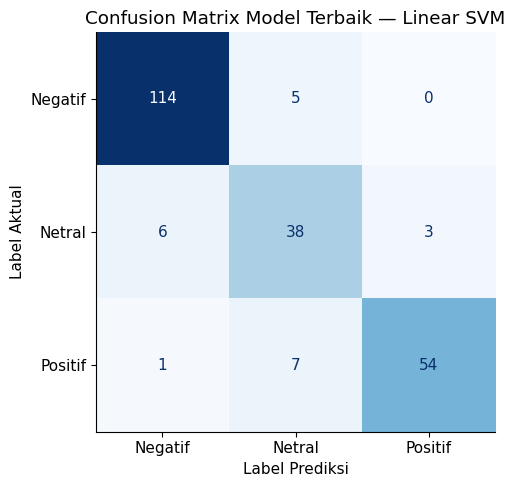

In [85]:
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=URUTAN_LABEL,
    display_labels=[label.capitalize() for label in URUTAN_LABEL],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax_cm,
)

ax_cm.set_title(f"Confusion Matrix Model Terbaik — {nama_model_terbaik}")
ax_cm.set_xlabel("Label Prediksi")
ax_cm.set_ylabel("Label Aktual")
fig_cm.tight_layout()

PATH_CONFUSION_MATRIX = os.path.join(FOLDER_GRAFIK, "confusion_matrix.png")
fig_cm.savefig(PATH_CONFUSION_MATRIX, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_cm)

### **Menyimpan Model**


In [86]:
teks_uji_simpan = "Aplikasi Mobile JKN sangat membantu"
teks_uji_preprocessing = preprocess_teks(teks_uji_simpan)
prediksi_sebelum_simpan = model_final.predict(
    tfidf_final.transform([teks_uji_preprocessing])
)[0]

joblib.dump(model_final, PATH_MODEL)
joblib.dump(tfidf_final, PATH_TFIDF)

model_muat = joblib.load(PATH_MODEL)
tfidf_muat = joblib.load(PATH_TFIDF)

prediksi_setelah_muat = model_muat.predict(
    tfidf_muat.transform([teks_uji_preprocessing])
)[0]

assert prediksi_sebelum_simpan == prediksi_setelah_muat
assert tfidf_muat.get_feature_names_out().tolist() == tfidf_final.get_feature_names_out().tolist()

print("Model tersimpan:", PATH_MODEL)
print("TF-IDF tersimpan:", PATH_TFIDF)

Model tersimpan: /content/drive/MyDrive/DA PPKD/PBL/Model.pkl, Tfidf.pkl dan Hasil Akhir Prediksi Sentimen/model.pkl
TF-IDF tersimpan: /content/drive/MyDrive/DA PPKD/PBL/Model.pkl, Tfidf.pkl dan Hasil Akhir Prediksi Sentimen/tfidf.pkl


**model.pkl** menyimpan Linear SVM yang sudah dilatih.

**tfidf.pkl** menyimpan cara mengubah teks menjadi fitur yang dipahami model.


### **Prediksi Sisa Data RAW dan Penggabungan Label**

Data yang sudah memiliki label manual tidak diprediksi ulang. Model hanya digunakan
untuk memprediksi data RAW yang belum dilabel **(10.670)**. Selanjutnya, label manual dan hasil
prediksi model digabungkan berdasarkan ID.

In [87]:
# Menyalin seluruh data RAW agar urutan dan kolom aslinya tetap terjaga
df_hasil = df_raw.copy()

# Membuat kolom bulan jika belum tersedia
if "bulan" not in df_hasil.columns:
    nomor_bulan = pd.to_datetime(
        df_hasil["tanggal"],
        errors="coerce"
    ).dt.month

    df_hasil["bulan"] = nomor_bulan.map({
        6: "Juni",
        7: "Juli",
        8: "Agustus"
    })


# =========================================================
# PREPROCESSING SELURUH DATA RAW
# =========================================================

tqdm.pandas(desc="Preprocessing data RAW")

df_hasil["teks_normalisasi"] = (
    df_hasil["teks"]
    .progress_apply(normalisasi_teks)
)

df_hasil["teks_preprocessing"] = (
    df_hasil["teks"]
    .progress_apply(preprocess_teks)
)


# =========================================================
# MEMASUKKAN LABEL MANUAL BERDASARKAN ID
# =========================================================

# Membuat pasangan ID dan label manual
label_manual_per_id = (
    df_label
    .set_index("id")["label_sentimen"]
)

# Memasukkan label manual ke data RAW berdasarkan ID
df_hasil["label_sentimen_manual"] = (
    df_hasil["id"]
    .map(label_manual_per_id)
)

# Menentukan data yang sudah dan belum dilabel manual
mask_manual = df_hasil["label_sentimen_manual"].notna()
mask_model = ~mask_manual

jumlah_manual_final = int(mask_manual.sum())
jumlah_model_final = int(mask_model.sum())

# Memastikan seluruh data berlabel manual ditemukan di data RAW
if jumlah_manual_final != len(df_label):
    raise ValueError(
        "Tidak semua ID dari data label manual ditemukan pada data RAW."
    )


# =========================================================
# MEMPREDIKSI DATA YANG BELUM DILABEL
# =========================================================

# Mengubah teks menjadi fitur TF-IDF
X_semua_raw_tfidf = tfidf_muat.transform(
    df_hasil["teks_preprocessing"]
)

# Mengambil fitur untuk data yang belum memiliki label manual
X_sisa_raw_tfidf = X_semua_raw_tfidf[
    mask_model.to_numpy()
]

# Menyiapkan kolom prediksi model
df_hasil["prediksi_sentimen"] = pd.Series(
    pd.NA,
    index=df_hasil.index,
    dtype="string"
)

# Model hanya memprediksi data yang belum dilabel manual
prediksi_sisa = model_muat.predict(
    X_sisa_raw_tfidf
)

df_hasil.loc[
    mask_model,
    "prediksi_sentimen"
] = prediksi_sisa


# =========================================================
# MEMBUAT LABEL SENTIMEN FINAL
# =========================================================

# Menggunakan label manual jika tersedia.
# Jika tidak tersedia, menggunakan hasil prediksi model.
df_hasil["label_sentimen_final"] = (
    df_hasil["label_sentimen_manual"]
    .fillna(df_hasil["prediksi_sentimen"])
    .astype("string")
)

# Menandai asal label
df_hasil["sumber_label"] = pd.Series(
    np.where(mask_manual, "manual", "model"),
    index=df_hasil.index,
    dtype="string"
)

# Menandai apakah teks memiliki fitur yang dikenali TF-IDF
df_hasil["fitur_dikenali"] = (
    X_semua_raw_tfidf.getnnz(axis=1) > 0
)


# =========================================================
# PEMERIKSAAN DAN PENYIMPANAN
# =========================================================

if len(df_hasil) != len(df_raw):
    raise ValueError(
        "Jumlah baris berubah setelah penggabungan label."
    )

if not df_hasil["label_sentimen_final"].isin(URUTAN_LABEL).all():
    raise ValueError(
        "Label sentimen final mengandung label yang tidak valid."
    )

# Menyimpan hasil akhir
df_hasil.to_csv(
    PATH_PREDIKSI,
    index=False,
    encoding="utf-8-sig"
)

print("Jumlah seluruh data:", len(df_hasil))
print("Menggunakan label manual:", jumlah_manual_final)
print("Menggunakan prediksi model:", jumlah_model_final)
print(
    "Data model tanpa fitur TF-IDF:",
    int(
        (~df_hasil.loc[mask_model, "fitur_dikenali"]).sum()
    )
)
print("Hasil akhir tersimpan:", PATH_PREDIKSI)

# Menampilkan jumlah data berdasarkan sumber label
display(
    pd.crosstab(
        df_hasil["sumber_label"],
        df_hasil["label_sentimen_final"]
    )
)

display(
    df_hasil[
        [
            "id",
            "teks",
            "label_sentimen_manual",
            "prediksi_sentimen",
            "label_sentimen_final",
            "sumber_label"
        ]
    ].head(10)
)

Preprocessing data RAW:   0%|          | 0/12105 [00:00<?, ?it/s]

Preprocessing data RAW:   0%|          | 0/12105 [00:00<?, ?it/s]

Jumlah seluruh data: 12105
Menggunakan label manual: 1435
Menggunakan prediksi model: 10670
Data model tanpa fitur TF-IDF: 265
Hasil akhir tersimpan: /content/drive/MyDrive/DA PPKD/PBL/Model.pkl, Tfidf.pkl dan Hasil Akhir Prediksi Sentimen/Hasil Akhir Final Distribusi Sentimen dari Prediksi Model.csv


label_sentimen_final,negatif,netral,positif
sumber_label,,,
manual,605,263,567
model,5204,667,4799


,id,teks,label_sentimen_manual,prediksi_sentimen,label_sentimen_final,sumber_label
0,afc4dbfc-10a7-4be4-a703-7d18b2898a78,"Makin parah nih apk nya. Iuran udah di bayar, tapi status keanggotaan nya masih tidak aktif. Ini saya mau cek iuran ...",NaN,negatif,negatif,model
1,3bac7ee0-3beb-438c-b242-08bfe9547e9a,aplikasi JKN ini sangat mempermudah dalam pelayanan kesehatan kami sekeluarga,NaN,positif,positif,model
2,6dad03f2-eff6-4c20-8eea-cb3c3fa21030,APLIKASI KALAU LAGI URGENT DI BUTUHKAN MALAH OFFLINE ! MANTAP,NaN,negatif,negatif,model
3,52a1e12d-ea2a-4b1a-9a57-29136404c66e,"Setiap kali mau daftar ke faskes tingkat lanjut itu susah banget, selalu dapet tulisan ""Gagal tersambung ke server R...",NaN,negatif,negatif,model
4,c4e4a82c-89e0-40d1-b1ae-9a26200bd041,"ribet, tidak fleksibel dan sering error ☹️",NaN,negatif,negatif,model
5,bc405e85-a6c2-4685-85fb-d1dc79ea2be7,asik,NaN,netral,netral,model
6,40add313-d49e-4def-a733-1c8168717091,mudah diakses dan gampang digunakan,NaN,positif,positif,model
7,5a560ee9-3898-4485-8e08-261a48ccc61a,mantap,NaN,positif,positif,model
8,855a3e90-5467-4e9c-a2d7-7f1b068d76e2,bagus,positif,<NA>,positif,manual
9,2090abb7-8010-4ba0-add3-32dfcd979e80,"praktis, mudah",NaN,positif,positif,model


## **10. Distribusi Sentimen Final**



,Jumlah Ulasan,Persentase (%)
Sentimen,,
negatif,5809,47.99
netral,930,7.68
positif,5366,44.33


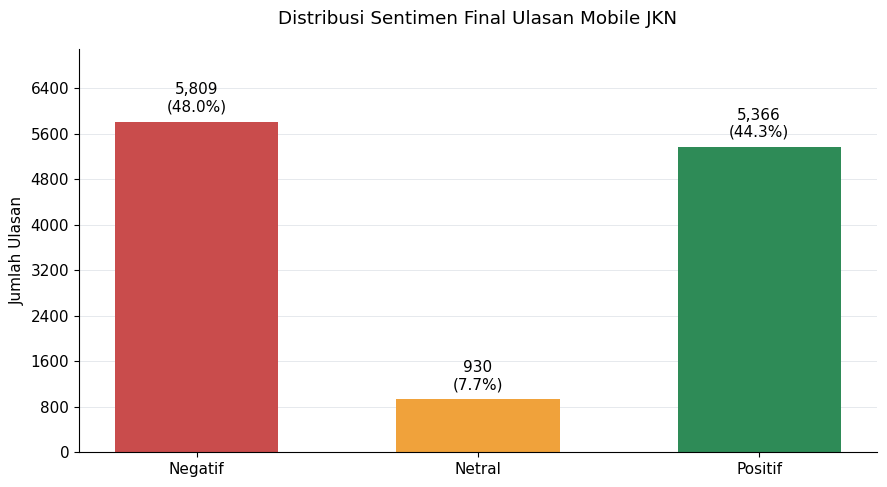

**Insight:** sentimen **negatif** paling dominan dengan **5,809 ulasan (47.99%)** dari label final gabungan seluruh data RAW.

In [88]:
jumlah_sentimen = (
    df_hasil["label_sentimen_final"]
    .value_counts()
    .reindex(URUTAN_LABEL, fill_value=0)
    .astype(int)
)
persentase_sentimen = jumlah_sentimen / len(df_hasil) * 100

distribusi_sentimen = pd.DataFrame({
    "Jumlah Ulasan": jumlah_sentimen,
    "Persentase (%)": persentase_sentimen.round(2),
})
distribusi_sentimen.index.name = "Sentimen"
display(distribusi_sentimen)

sentimen_dominan = jumlah_sentimen.idxmax()

fig_distribusi, ax_distribusi = plt.subplots(figsize=(9, 5))
batang = ax_distribusi.bar(
    [label.capitalize() for label in URUTAN_LABEL],
    jumlah_sentimen,
    color=[WARNA_SENTIMEN[label] for label in URUTAN_LABEL],
    width=0.58,
)

label_batang = [
    f"{jumlah:,}\n({persen:.1f}%)"
    for jumlah, persen in zip(jumlah_sentimen, persentase_sentimen)
]
ax_distribusi.bar_label(batang, labels=label_batang, padding=5, fontsize=11)
ax_distribusi.set_title("Distribusi Sentimen Final Ulasan Mobile JKN", pad=18)
ax_distribusi.set_ylabel("Jumlah Ulasan")
ax_distribusi.set_ylim(0, max(int(jumlah_sentimen.max()), 1) * 1.22)
ax_distribusi.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_distribusi.grid(axis="y", color="#E6E9ED", linewidth=0.7)
ax_distribusi.set_axisbelow(True)
fig_distribusi.tight_layout()

PATH_DISTRIBUSI = os.path.join(FOLDER_GRAFIK, "distribusi_sentimen.png")
fig_distribusi.savefig(PATH_DISTRIBUSI, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_distribusi)

display(Markdown(
    f"**Insight:** sentimen **{sentimen_dominan}** paling dominan dengan "
    f"**{jumlah_sentimen[sentimen_dominan]:,} ulasan "
    f"({persentase_sentimen[sentimen_dominan]:.2f}%)** dari label final gabungan seluruh data RAW."
))

## **11. WordCloud**



In [89]:
# =========================================================
# PENGATURAN WORDCLOUD
# =========================================================

# Hanya frasa tertentu yang harus dibaca berpasangan
FRASA_WORDCLOUD = {
    # Frasa keluhan
    "tidak bisa",
    "tidak masuk",
    "tidak muncul",
    "tidak jelas",
    "tidak lancar",
    "tidak membantu",
    "tidak mudah",
    "tidak bagus",
    "tidak baik",
    "tidak berfungsi",
    "tidak terkirim",
    "tidak sesuai",
    "tidak sulit",
    "tidak susah",
    "tidak rumit",
    "tidak lambat",
    "tidak gagal",
    "tidak error",
    "tidak masalah",
    "kode otp",
    "kata sandi",
    "verifikasi wajah",
    "rumah sakit",
    "gagal login",
    "gagal masuk",
    "susah login",
    "sulit login",
    "nomor antrean",
    "terus menerus",
    "sangat susah",
    "sangat sulit",
    "sangat lambat",
    "sangat rumit",

    # Frasa pujian
    "sangat membantu",
    "sangat bagus",
    "sangat baik",
    "sangat mudah",
    "sangat bermanfaat",
    "sangat memuaskan",
    "terima kasih",
    "mudah digunakan",
    "membantu sekali",
}

# Kata penting yang tetap boleh ditampilkan sendiri
KATA_PENTING_WORDCLOUD = {
    "otp", "kode", "login", "masuk", "daftar",
    "verifikasi", "wajah", "server", "faskes",
    "antrean", "nomor", "pelayanan", "ponsel",
    "update", "sandi", "mudah", "membantu",
    "bagus", "baik", "lancar", "error",
    "gagal", "susah", "sulit", "rumit",
}

# Kata umum yang tidak perlu ditampilkan sendiri
STOPWORDS_TAMBAHAN_WORDCLOUD = {
    "aplikasi", "aplikasinya", "mobile", "jkn", "bpjs", "nya",
    "mau", "sangat", "tidak", "bisa", "terus", "sekali",
    "terima", "kasih", "pada", "buat", "kalau", "sama",
    "sendiri", "jadi", "coba", "apa", "bagaimana", "orang",
    "banyak", "kali", "pakai", "padahal", "malah", "masih",
    "sudah", "lagi", "hanya", "tetap",
}

# Stopword ini hanya digunakan pada WordCloud
STOPWORDS_WORDCLOUD = (
    (set(stopword_awal) - KATA_PENTING_WORDCLOUD)
    | STOPWORDS_TAMBAHAN_WORDCLOUD
)


def hitung_frekuensi_wordcloud(kumpulan_teks):
    """
    Menghitung kata tunggal dan hanya mempertahankan frasa
    yang terdapat dalam FRASA_WORDCLOUD.
    """
    frekuensi = Counter()

    for teks in kumpulan_teks.dropna().astype(str):
        token = [
            kata
            for kata in teks.casefold().split()
            if len(kata) > 1 and not kata.isdigit()
        ]

        indeks = 0

        while indeks < len(token):
            # Memeriksa apakah dua kata harus ditampilkan berpasangan
            if indeks + 1 < len(token):
                pasangan = f"{token[indeks]} {token[indeks + 1]}"

                if pasangan in FRASA_WORDCLOUD:
                    frekuensi[pasangan] += 1
                    indeks += 2
                    continue

            # Kata lainnya tetap dihitung sebagai kata tunggal
            kata = token[indeks]

            if kata not in STOPWORDS_WORDCLOUD:
                frekuensi[kata] += 1

            indeks += 1

    return frekuensi


### **Negatif**

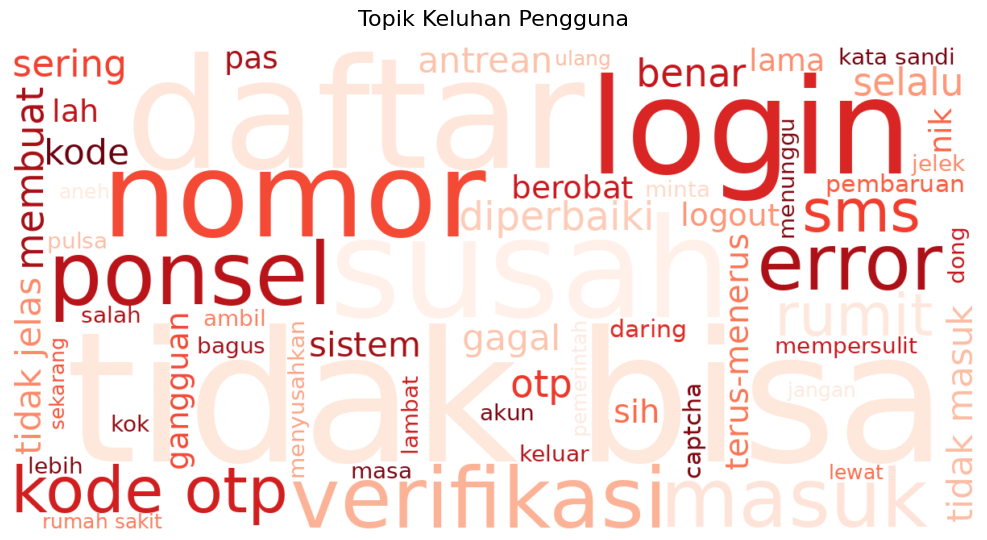

Sepuluh kata atau frasa keluhan yang paling sering muncul:


,Kata/Frasa Keluhan,Frekuensi
0,tidak bisa,1949
1,daftar,1347
2,susah,1073
3,login,1000
4,nomor,904
5,ponsel,788
6,verifikasi,740
7,masuk,680
8,error,614
9,kode otp,540


**Insight WordCloud negatif:** topik keluhan paling dominan adalah **tidak bisa** sebanyak **1,949 kali**.

WordCloud negatif tersimpan: /content/drive/MyDrive/DA PPKD/PBL/Output Hasil Analisis/Grafik & Wordcloud/wordcloud_keluhan_negatif.png


In [90]:
# =========================================================
# WORDCLOUD KELUHAN — SENTIMEN NEGATIF
# =========================================================

teks_negatif = df_hasil.loc[
    df_hasil["label_sentimen_final"].eq("negatif"),
    "teks_normalisasi",
]

frekuensi_keluhan = hitung_frekuensi_wordcloud(teks_negatif)

fig_keluhan, ax_keluhan = plt.subplots(figsize=(10, 6))

if frekuensi_keluhan:
    wordcloud_keluhan = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        colormap="Reds",
        font_path=findfont("DejaVu Sans"),
        random_state=RANDOM_STATE,
        max_words=60,
        collocations=False,
    ).generate_from_frequencies(frekuensi_keluhan)

    ax_keluhan.imshow(
        wordcloud_keluhan,
        interpolation="bilinear"
    )
else:
    ax_keluhan.text(
        0.5,
        0.5,
        "Data negatif tidak tersedia",
        ha="center",
        va="center",
    )

ax_keluhan.set_title(
    "Topik Keluhan Pengguna",
    fontsize=16,
    pad=15
)
ax_keluhan.axis("off")
fig_keluhan.tight_layout()

PATH_WORDCLOUD_NEGATIF = os.path.join(
    FOLDER_GRAFIK,
    "wordcloud_keluhan_negatif.png",
)

fig_keluhan.savefig(
    PATH_WORDCLOUD_NEGATIF,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig_keluhan)

top_keluhan = pd.DataFrame(
    frekuensi_keluhan.most_common(10),
    columns=["Kata/Frasa Keluhan", "Frekuensi"],
)

print("Sepuluh kata atau frasa keluhan yang paling sering muncul:")
display(top_keluhan)

top_keluhan.to_csv(
    os.path.join(FOLDER_HASIL, "top_10_kata_keluhan.csv"),
    index=False,
    encoding="utf-8-sig",
)

if not top_keluhan.empty:
    display(Markdown(
        f"**Insight WordCloud negatif:** topik keluhan paling dominan adalah "
        f"**{top_keluhan.loc[0, 'Kata/Frasa Keluhan']}** sebanyak "
        f"**{int(top_keluhan.loc[0, 'Frekuensi']):,} kali**."
    ))

print("WordCloud negatif tersimpan:", PATH_WORDCLOUD_NEGATIF)

In [91]:
# =========================================================
# CONTOH ULASAN ASLI BERDASARKAN TOPIK WORDCLOUD
# =========================================================

def ambil_contoh_ulasan(
    data,
    sentimen,
    frekuensi_topik,
    jumlah_topik=5,
    contoh_per_topik=3,
):
    """Mengambil contoh ulasan asli dari topik WordCloud yang paling sering muncul."""
    hasil = []

    # Mengambil data sesuai sentimen
    data_sentimen = (
        data.loc[
            data["label_sentimen_final"].eq(sentimen),
            ["teks", "teks_normalisasi"]
        ]
        .drop_duplicates(subset="teks")
        .copy()
    )

    # Mengambil kata atau frasa dengan frekuensi tertinggi
    for topik, frekuensi in frekuensi_topik.most_common(jumlah_topik):
        pola_topik = rf"(?<!\w){re.escape(topik)}(?!\w)"

        # Mencari ulasan yang mengandung topik tersebut
        kandidat = (
            data_sentimen.loc[
                data_sentimen["teks_normalisasi"].str.contains(
                    pola_topik,
                    case=False,
                    regex=True,
                    na=False,
                ),
                "teks"
            ]
            .dropna()
            .drop_duplicates()
        )

        # Mengambil contoh secara tetap agar hasil tidak berubah
        if len(kandidat) > contoh_per_topik:
            contoh_ulasan = kandidat.sample(
                n=contoh_per_topik,
                random_state=RANDOM_STATE,
            ).tolist()
        else:
            contoh_ulasan = kandidat.tolist()

        for nomor, ulasan in enumerate(contoh_ulasan, start=1):
            hasil.append({
                "Sentimen": sentimen.capitalize(),
                "Kata/Frasa": topik,
                "Frekuensi": frekuensi,
                "Contoh ke-": nomor,
                "Ulasan Asli": ulasan,
            })

    return pd.DataFrame(hasil)


# Mengambil contoh ulasan negatif
contoh_ulasan_negatif = ambil_contoh_ulasan(
    data=df_hasil,
    sentimen="negatif",
    frekuensi_topik=frekuensi_keluhan,
    jumlah_topik=5,
    contoh_per_topik=3,
)

display(Markdown("### Contoh Ulasan Asli dari Topik Keluhan Teratas"))
display(contoh_ulasan_negatif)

### Contoh Ulasan Asli dari Topik Keluhan Teratas

,Sentimen,Kata/Frasa,Frekuensi,Contoh ke-,Ulasan Asli
0,Negatif,tidak bisa,1949,1,"aplikasi gak guna, ini aplikasi mau nya gimana sih min? saya bela²in beli nomer baru tetep nggak bisa, ternyata kalo..."
1,Negatif,tidak bisa,1949,2,"setelah di update kualitas jaringannya malah semakin buruk, saya tdk bisa mengakses apk ini."
2,Negatif,tidak bisa,1949,3,"Tolong perbaiki dong, ga bisa login offline trus padahal sinyal udah baguss"
3,Negatif,daftar,1347,1,apk kayak apa ini kok mau daftar gak bisa pakai nomer XL gak bisa kalau pakai no tri bisa sedangkan saya gak punya n...
4,Negatif,daftar,1347,2,Apk yg katanya buat mempermudah masyarakat nyatanya buat daftar aja error mulu. perbaiki lagi layanan sms ke nomer h...
5,Negatif,daftar,1347,3,"daftar online memudah kan pelayanan, tapi menyusahkan kalo gk dpt no antrian terus 🙏 apalagi stiap maun ambil antrea..."
6,Negatif,susah,1073,1,"aplikasi tidak berguna, verifikasi susah sekali"
7,Negatif,susah,1073,2,log in susah masuk
8,Negatif,susah,1073,3,"mau login aja susahnya minta ampun, mulai dari captcha yang ketinggalan jaman dan lama loadingnya, susah masuk serve..."
9,Negatif,login,1000,1,setiap mau login daftar selalu gangguan terus aplikasinya tolong dong gimana ini


### **Positif**

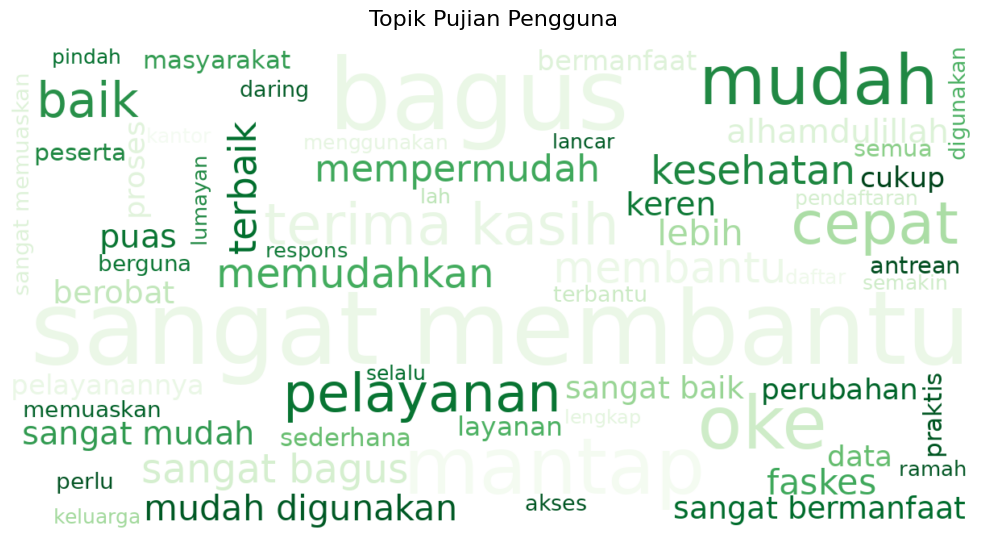

Sepuluh kata atau frasa pujian yang paling sering muncul:


,Kata/Frasa Pujian,Frekuensi
0,sangat membantu,1158
1,bagus,1081
2,mantap,617
3,oke,547
4,mudah,473
5,cepat,353
6,terima kasih,324
7,pelayanan,282
8,baik,232
9,membantu,177


**Insight WordCloud positif:** topik pujian paling dominan adalah **sangat membantu** sebanyak **1,158 kali**.

WordCloud positif tersimpan: /content/drive/MyDrive/DA PPKD/PBL/Output Hasil Analisis/Grafik & Wordcloud/wordcloud_pujian_positif.png


In [92]:
# =========================================================
# WORDCLOUD PUJIAN — SENTIMEN POSITIF
# =========================================================

teks_positif = df_hasil.loc[
    df_hasil["label_sentimen_final"].eq("positif"),
    "teks_normalisasi",
]

frekuensi_pujian = hitung_frekuensi_wordcloud(teks_positif)

fig_pujian, ax_pujian = plt.subplots(figsize=(10, 6))

if frekuensi_pujian:
    wordcloud_pujian = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        colormap="Greens",
        font_path=findfont("DejaVu Sans"),
        random_state=RANDOM_STATE,
        max_words=60,
        collocations=False,
    ).generate_from_frequencies(frekuensi_pujian)

    ax_pujian.imshow(
        wordcloud_pujian,
        interpolation="bilinear"
    )
else:
    ax_pujian.text(
        0.5,
        0.5,
        "Data positif tidak tersedia",
        ha="center",
        va="center",
    )

ax_pujian.set_title(
    "Topik Pujian Pengguna",
    fontsize=16,
    pad=15
)
ax_pujian.axis("off")
fig_pujian.tight_layout()

PATH_WORDCLOUD_POSITIF = os.path.join(
    FOLDER_GRAFIK,
    "wordcloud_pujian_positif.png",
)

fig_pujian.savefig(
    PATH_WORDCLOUD_POSITIF,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig_pujian)

top_pujian = pd.DataFrame(
    frekuensi_pujian.most_common(10),
    columns=["Kata/Frasa Pujian", "Frekuensi"],
)

print("Sepuluh kata atau frasa pujian yang paling sering muncul:")
display(top_pujian)

top_pujian.to_csv(
    os.path.join(FOLDER_HASIL, "top_10_kata_pujian.csv"),
    index=False,
    encoding="utf-8-sig",
)

if not top_pujian.empty:
    display(Markdown(
        f"**Insight WordCloud positif:** topik pujian paling dominan adalah "
        f"**{top_pujian.loc[0, 'Kata/Frasa Pujian']}** sebanyak "
        f"**{int(top_pujian.loc[0, 'Frekuensi']):,} kali**."
    ))

print("WordCloud positif tersimpan:", PATH_WORDCLOUD_POSITIF)

In [93]:
# Mengambil contoh ulasan positif
contoh_ulasan_positif = ambil_contoh_ulasan(
    data=df_hasil,
    sentimen="positif",
    frekuensi_topik=frekuensi_pujian,
    jumlah_topik=5,
    contoh_per_topik=3,
)

display(Markdown("### Contoh Ulasan Asli dari Topik Pujian Teratas"))
display(contoh_ulasan_positif)

### Contoh Ulasan Asli dari Topik Pujian Teratas

,Sentimen,Kata/Frasa,Frekuensi,Contoh ke-,Ulasan Asli
0,Positif,sangat membantu,1158,1,Sangat Membantu ketika Pemindahan Paskes dan proses nya cepat
1,Positif,sangat membantu,1158,2,sangat membantu ketika sakit dan butuh informasi bantuan .
2,Positif,sangat membantu,1158,3,sangat Membantu
3,Positif,bagus,1081,1,wonderful
4,Positif,bagus,1081,2,pelayanan cepat bagus tanpa keluar rumah
5,Positif,bagus,1081,3,sangat Bagus
6,Positif,mantap,617,1,mantap bisa pindah paskes nya cepat 👍👍👍
7,Positif,mantap,617,2,mntap
8,Positif,mantap,617,3,mantap aplikasi sampah
9,Positif,oke,547,1,ok. lah


## **12. Analisis Jam Puncak Ulasan**

Jam puncak dihitung langsung dari `df_raw`. Tahap labeling, preprocessing, dan
prediksi sentimen tidak digunakan sehingga nilai waktu tetap sama seperti data
asli.


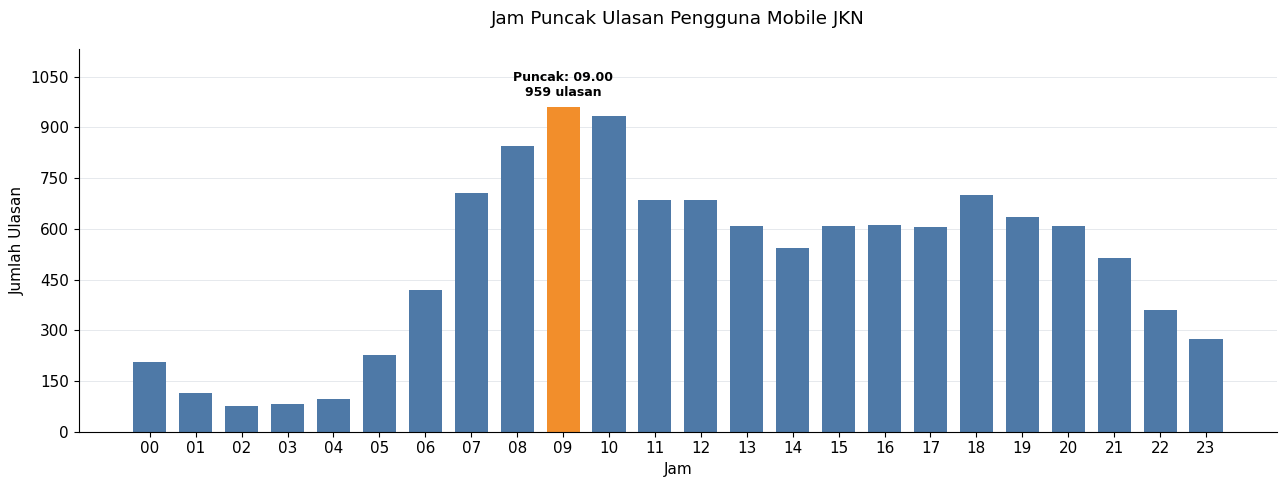

**Insight:** jam puncak pengiriman ulasan adalah **09.00–09.59** dengan **959 ulasan**. Ini menunjukkan waktu ulasan dikirim, bukan waktu pasti terjadinya kendala.

In [94]:
# Mengambil jam langsung dari dataset RAW
jam_analisis = pd.to_numeric(df_raw["jam"], errors="coerce")

if not jam_analisis.isin(range(24)).all():
    jam_dari_tanggal = pd.to_datetime(df_raw["tanggal"], errors="coerce").dt.hour
    jam_analisis = jam_analisis.where(jam_analisis.isin(range(24)), jam_dari_tanggal)

if not jam_analisis.isin(range(24)).all():
    raise ValueError("Masih terdapat nilai jam di luar rentang 0–23.")

jumlah_per_jam = (
    jam_analisis.astype(int)
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

jumlah_jam_puncak = int(jumlah_per_jam.max())
daftar_jam_puncak = jumlah_per_jam.index[
    jumlah_per_jam.eq(jumlah_jam_puncak)
].tolist()

warna_jam = [
    "#F28E2B" if jam in daftar_jam_puncak else "#4E79A7"
    for jam in range(24)
]

fig_jam, ax_jam = plt.subplots(figsize=(13, 5))
batang_jam = ax_jam.bar(range(24), jumlah_per_jam, color=warna_jam, width=0.72)
ax_jam.set_xticks(range(24), [f"{jam:02d}" for jam in range(24)])
ax_jam.set_xlabel("Jam")
ax_jam.set_ylabel("Jumlah Ulasan")
ax_jam.set_title("Jam Puncak Ulasan Pengguna Mobile JKN", pad=18)
ax_jam.set_ylim(0, max(jumlah_jam_puncak, 1) * 1.18)
ax_jam.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_jam.grid(axis="y", color="#E6E9ED", linewidth=0.7)
ax_jam.set_axisbelow(True)

for jam in daftar_jam_puncak:
    ax_jam.annotate(
        f"Puncak: {jam:02d}.00\n{jumlah_jam_puncak:,} ulasan",
        xy=(jam, jumlah_jam_puncak),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

fig_jam.tight_layout()
PATH_JAM = os.path.join(FOLDER_GRAFIK, "jam_puncak_ulasan.png")
fig_jam.savefig(PATH_JAM, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_jam)

teks_jam_puncak = ", ".join(f"{jam:02d}.00–{jam:02d}.59" for jam in daftar_jam_puncak)
display(Markdown(
    f"**Insight:** jam puncak pengiriman ulasan adalah **{teks_jam_puncak}** "
    f"dengan **{jumlah_jam_puncak:,} ulasan**. Ini menunjukkan waktu ulasan "
    "dikirim, bukan waktu pasti terjadinya kendala."
))

## **13. Rating vs Sentimen**

Setiap rating memiliki tiga batang: negatif, netral, dan positif. Rating hanya
dipakai untuk analisis setelah prediksi, bukan sebagai fitur atau pembentuk label.

label_sentimen_final,negatif,netral,positif
Rating,,,
1,4377,137,37
2,513,19,7
3,339,25,33
4,188,68,233
5,392,681,5056


Persentase dalam setiap rating:


label_sentimen_final,negatif,netral,positif
Rating,,,
1,96.18,3.01,0.81
2,95.18,3.53,1.30
3,85.39,6.30,8.31
4,38.45,13.91,47.65
5,6.40,11.11,82.49


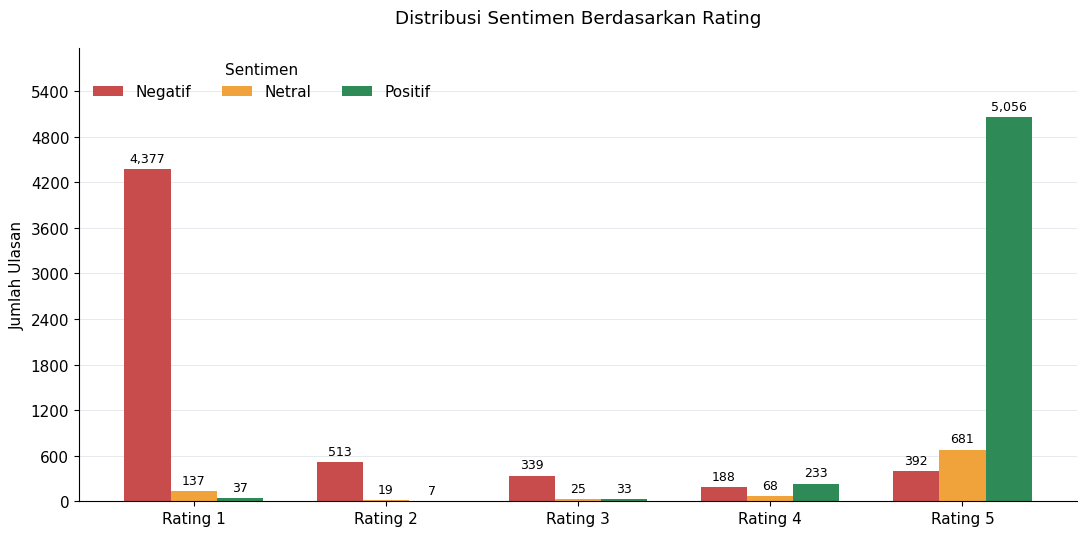

In [95]:
rating_analisis = pd.to_numeric(df_hasil["rating"], errors="coerce")
mask_rating_valid = rating_analisis.isin([1, 2, 3, 4, 5])

tabel_rating = pd.crosstab(
    rating_analisis.loc[mask_rating_valid].astype(int),
    df_hasil.loc[
        mask_rating_valid,
        "label_sentimen_final"
    ],
).reindex(
    index=[1, 2, 3, 4, 5],
    columns=URUTAN_LABEL,
    fill_value=0
)
tabel_rating.index.name = "Rating"

persentase_rating = (
    tabel_rating
    .div(tabel_rating.sum(axis=1).replace(0, np.nan), axis=0)
    .mul(100)
    .fillna(0)
)

display(tabel_rating)
print("Persentase dalam setiap rating:")
display(persentase_rating.round(2))

posisi_rating = np.arange(5)
lebar_batang = 0.24
fig_rating, ax_rating = plt.subplots(figsize=(11, 5.5))

for nomor, label in enumerate(URUTAN_LABEL):
    nilai = tabel_rating[label].to_numpy()
    batang = ax_rating.bar(
        posisi_rating + (nomor - 1) * lebar_batang,
        nilai,
        width=lebar_batang,
        color=WARNA_SENTIMEN[label],
        label=label.capitalize(),
    )
    ax_rating.bar_label(
        batang,
        labels=[f"{nilai_batang:,}" if nilai_batang else "" for nilai_batang in nilai],
        padding=3,
        fontsize=9,
    )

ax_rating.set_xticks(posisi_rating, [f"Rating {rating}" for rating in range(1, 6)])
ax_rating.set_ylabel("Jumlah Ulasan")
ax_rating.set_title("Distribusi Sentimen Berdasarkan Rating", pad=18)
ax_rating.set_ylim(0, max(int(tabel_rating.to_numpy().max()), 1) * 1.18)
ax_rating.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_rating.legend(title="Sentimen", frameon=False, ncols=3)
ax_rating.grid(axis="y", color="#E6E9ED", linewidth=0.7)
ax_rating.set_axisbelow(True)
fig_rating.tight_layout()

PATH_RATING = os.path.join(FOLDER_GRAFIK, "sentimen_berdasarkan_rating.png")
fig_rating.savefig(PATH_RATING, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_rating)

tabel_rating.to_csv(
    os.path.join(FOLDER_HASIL, "jumlah_sentimen_berdasarkan_rating.csv"),
    encoding="utf-8-sig",
)

Terdapat kecenderungan yang konsisten antara rating dan hasil klasifikasi sentimen. Rating rendah didominasi sentimen negatif, sedangkan rating tinggi didominasi sentimen positif. Hal ini menunjukkan bahwa hasil klasifikasi secara umum mampu menangkap kecenderungan pola ulasan.

Hal ini didukung dengan hasil evaluasi pada data test, model memiliki performa yang kuat dalam mengenali sentimen negatif dan positif. Kelas negatif memiliki **F1 sekitar 95% dan positif sekitar 91%**.

## **14. Deployment Gradio**

Aplikasi memiliki dua tab: prediksi ulasan baru dan dashboard hasil analisis.
Model serta TF-IDF hanya dimuat dan digunakan untuk `transform()` serta
`predict()`—tidak ada training atau `fit()` di bagian ini.

In [96]:
import gradio as gr

model_gradio = joblib.load(PATH_MODEL)
tfidf_gradio = joblib.load(PATH_TFIDF)


def prediksi_gradio(teks):
    if not str(teks).strip():
        return "Masukkan ulasan terlebih dahulu.", ""

    teks_preprocessing = preprocess_teks(teks)
    fitur_input = tfidf_gradio.transform([teks_preprocessing])
    label_prediksi = model_gradio.predict(fitur_input)[0]

    return label_prediksi.capitalize()


ringkasan_dashboard = (
    f"**Model terbaik:** {nama_model_terbaik}  \n"
    f"**F1 Macro test:** {metrik_test.loc[0, 'F1 Macro Test']:.4f}  \n"
    f"**Sentimen dominan:** {sentimen_dominan} "
    f"({persentase_sentimen[sentimen_dominan]:.2f}%)  \n"
    f"**Jam puncak:** {teks_jam_puncak} ({jumlah_jam_puncak:,} ulasan)"
)

with gr.Blocks(title="Analisis Sentimen Mobile JKN") as demo:
    gr.Markdown("# Analisis Sentimen Ulasan Mobile JKN")

    with gr.Tab("Prediksi Ulasan"):
        input_ulasan = gr.Textbox(
            label="Masukkan ulasan Mobile JKN",
            lines=5,
            placeholder="Contoh: Aplikasi sangat membantu dan mudah digunakan",
        )
        with gr.Row():
            tombol_prediksi = gr.Button("Prediksi", variant="primary")
            tombol_bersih = gr.ClearButton(value="Bersihkan")

        output_label = gr.Textbox(label="Prediksi Sentimen", interactive=False)

        tombol_prediksi.click(
            fn=prediksi_gradio,
            inputs=input_ulasan,
            outputs=output_label,
        )
        tombol_bersih.add([input_ulasan, output_label])

        gr.Examples(
            examples=[
                ["Aplikasi sangat membantu dan mudah digunakan"],
                ["Tidak bisa login dan kode OTP belum masuk"],
                ["Semoga pelayanan semakin baik"],
            ],
            inputs=input_ulasan,
        )

    with gr.Tab("Dashboard Analisis"):
        gr.Markdown(ringkasan_dashboard)
        gr.Image(value=PATH_DISTRIBUSI, label="Distribusi Sentimen", interactive=False)
        gr.Dataframe(value=hasil_benchmark.round(4), label="Benchmark Model", interactive=False)
        gr.Image(value=PATH_JAM, label="Jam Puncak Ulasan", interactive=False)
        with gr.Row():
              gr.Image(
                  value=PATH_WORDCLOUD_NEGATIF,
                  label="WordCloud Keluhan",
                  interactive=False
              )

              gr.Image(
                  value=PATH_WORDCLOUD_POSITIF,
                  label="WordCloud Pujian",
                  interactive=False
              )
        gr.Image(value=PATH_RATING, label="Sentimen Berdasarkan Rating", interactive=False)

# Tautan gradio.live bersifat sementara dan aktif selama runtime Colab berjalan.
JALANKAN_GRADIO = os.environ.get("JALANKAN_GRADIO", "1") == "1"

if JALANKAN_GRADIO:
    demo.launch(share=True)
else:
    print("Interface Gradio berhasil dibuat; launch dilewati saat pemeriksaan lokal.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66f3b6b0116c0600bd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
